In [68]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

def consolidar_transferencias(url_diferidas, url_inmediatas):
    """
    Consolida transferencias diferidas e inmediatas en un único DataFrame.

    Parameters
    ----------
    url_diferidas : str
        Ruta del archivo TDS (Diferidas).
    url_inmediatas : str
        Ruta del archivo TIS (Inmediatas).

    Returns
    -------
    pd.DataFrame
        DataFrame consolidado.
    """

    # =========================
    # Lectura de archivos
    # =========================
    df_1 = pd.read_csv(url_diferidas, sep=';', encoding='latin-1')
    df_2 = pd.read_csv(url_inmediatas, sep=';', encoding='latin-1')

    df_1.columns = df_1.columns.str.strip()
    df_2.columns = df_2.columns.str.strip()

    # =========================
    # Formateo de horas
    # =========================
    df_1['HORA TRANSFERENCIA'] = (
        df_1['HORA TRANSFERENCIA']
        .astype(float)
        .astype(int)
        .astype(str)
        .str.zfill(6)
        .str.replace(r'(\d{2})(\d{2})(\d{2})',
                     r'\1:\2:\3',
                     regex=True)
    )

    df_2['HORA PROCESO'] = (
        df_2['HORA PROCESO']
        .astype(float)
        .astype(int)
        .astype(str)
        .str.zfill(6)
        .str.replace(r'(\d{2})(\d{2})(\d{2})',
                     r'\1:\2:\3',
                     regex=True)
    )

    # =========================
    # Mapeo de bancos
    # =========================
    mapeo_bancos = {
        'BCP BANCO DE CRÉDITO': 'BANCO DE CREDITO',
        'BCO.DE LA NACION': 'BANCO DE LA NACION',
        'BCO.DE COMERCIO': 'BANCOMER',
        'CAJA METROPOLITA': 'CAJA METROPOLITANA DE LIMA',
        'CMAC PIURA S.A.C': 'CAJA PIURA',
        'CONFIANZA': 'FINANCIERA CONFIANZA',
        'CITIBANK': 'CITIBANK DEL PERU S.A.',
        'COMPARTAMOS': 'COMPARTAMOS FINANCIERA',
        'EEDE': 'EEDE TARJETAS PERUANAS',
        'B.I.F.': 'BANBIF',
        'BCO. FALABELLA': 'BANCO FALABELLA',
        'ALFIN BANCO': 'ALFIN BANCO S.A.',
        'SIP / AGORA / OH': 'SIP / AGORA / OH!',
        'BCO.SANTANDER': 'BANCO SANTANDER PERU S.A.',
        'GNB': 'BANCO GNB',
        'CMAC CUSCO': 'CAJA CUSCO',
        'CMAC AREQUIPA': 'CAJA AREQUIPA',
        'CMAC TRUJILLO': 'CAJA TRUJILLO',
        'CMAC ICA': 'CAJA ICA',
        'FINANCIERA EFECT': 'FINANCIERA EFECTIVA',
        'CAJA LOS ANDES': 'LOS ANDES'
    }

    for df in [df_1, df_2]:
        df['NOMBRE ENTIDAD DESTINO'] = (
            df['NOMBRE ENTIDAD DESTINO']
            .astype(str)
            .str.strip()
            .map(mapeo_bancos)
            .fillna(df['NOMBRE ENTIDAD DESTINO'].astype(str).str.strip())
        )

    # =========================
    # Filtros
    # =========================
    df_2_new = df_2[
        (df_2['DESCRIPCION CANAL'] == 'APP MOVIL') &
        (df_2['DESCRIPCION CLASE CLIENTE'] == 'CLTE. NATURAL') &
        (df_2['MONEDA ABONO'] == 'PEN')
    ].copy()

    df_1_new = df_1[
        (df_1['DESCRIPCION TIPO'] == 'CLTE. NATURAL') &
        (df_1['CANAL'] == 'APP MOVIL') &
        (df_1['MONEDA CARGO'] == 'PEN')
    ].copy()

    df_1_new['INTEROP. QR'] = ''

    # =========================
    # Estandarización Inmediatas
    # =========================
    df_inm_clean = df_2_new[[
        'CODIGO CLIENTE',
        'DESCRIPCION CLASE CLIENTE',
        'MONEDA ABONO',
        'FECHA PROCESO',
        'HORA PROCESO',
        'NOMBRE ENT ORIGEN',
        'NOMBRE ENTIDAD DESTINO',
        'DESCRIPCION CANAL',
        'NOMBRE CLIENTE ORIGEN',
        'NOMBRE CLIENTE BENEFICIARIO',
        'IMPORTE TRANSFERENCIA',
        'INTEROP. QR'
    ]].copy()

    df_inm_clean.columns = [
        'CODIGO CLIENTE',
        'TIPO CLIENTE',
        'MONEDA ABONO',
        'FECHA TRANSFERENCIA',
        'HORA TRANSFERENCIA',
        'NOMBRE ENT ORIGEN',
        'NOMBRE ENTIDAD DESTINO',
        'CANAL',
        'NOMBRE CLIENTE ORIGINANTE',
        'NOMBRE CLIENTE DESTINO',
        'IMPORTE TRANSFERENCIA',
        'INTEROP. QR'
    ]

    df_inm_clean['Tipo'] = 'Inmediatas'

    # =========================
    # Estandarización Diferidas
    # =========================
    df_dif_clean = df_1_new[[
        'CODIGO CLIENTE',
        'DESCRIPCION TIPO',
        'MONEDA ABONO',
        'FECHA DE TRANSFERENCIA',
        'HORA TRANSFERENCIA',
        'NOMBRE ENT ORIGEN',
        'NOMBRE ENTIDAD DESTINO',
        'CANAL',
        'NOMBRE CLIENTE  ORIGINANTE',
        'NOMBRE CLIENTE DESTINO',
        'IMPORTE TRANSFERENCIA',
        'INTEROP. QR'
    ]].copy()

    df_dif_clean.columns = [
        'CODIGO CLIENTE',
        'TIPO CLIENTE',
        'MONEDA ABONO',
        'FECHA TRANSFERENCIA',
        'HORA TRANSFERENCIA',
        'NOMBRE ENT ORIGEN',
        'NOMBRE ENTIDAD DESTINO',
        'CANAL',
        'NOMBRE CLIENTE ORIGINANTE',
        'NOMBRE CLIENTE DESTINO',
        'IMPORTE TRANSFERENCIA',
        'INTEROP. QR'
    ]

    df_dif_clean['Tipo'] = 'Diferidas'

    # =========================
    # Consolidación final
    # =========================
    df_consolidado = pd.concat(
        [df_inm_clean, df_dif_clean],
        ignore_index=True
    )

    df_consolidado['INTEROP. QR'] = df_consolidado['INTEROP. QR'].replace(r'^\s*$', np.nan, regex=True)
    df_consolidado['INTEROP. QR'] = df_consolidado['INTEROP. QR'].fillna('TRANSFERENCIA')

    print(f"Total registros unificados: {len(df_consolidado)}")
    print(df_consolidado['Tipo'].value_counts())
    
    return df_consolidado


url_1 = r'D:\Users\SAUOCH\Downloads\TDS_20260709_111723_3_BFPCESVIE (1).csv'
url_2 = r'D:\Users\SAUOCH\Downloads\TIS_20260709_104046_1_BFPCESVIE (1).csv'

df_consolidado = consolidar_transferencias(url_1, url_2)

df_consolidado.head()

Total registros unificados: 721497
Tipo
Inmediatas    718588
Diferidas       2909
Name: count, dtype: int64


,CODIGO CLIENTE,TIPO CLIENTE,MONEDA ABONO,FECHA TRANSFERENCIA,HORA TRANSFERENCIA,NOMBRE ENT ORIGEN,NOMBRE ENTIDAD DESTINO,CANAL,NOMBRE CLIENTE ORIGINANTE,NOMBRE CLIENTE DESTINO,IMPORTE TRANSFERENCIA,INTEROP. QR,Tipo
0,3599440,CLTE. NATURAL,PEN,20260601,00:05:08,BANCO PICHINCHA,nan,APP MOVIL,JONATAN JOSUE ANCHANTE CLAUSEN,NaN,20.0,ENVIO CONTACTO,Inmediatas
1,3599440,CLTE. NATURAL,PEN,20260601,00:05:12,BANCO PICHINCHA,BANCO DE CREDITO,APP MOVIL,JONATAN JOSUE ANCHANTE CLAUSEN,JONATAN JOSUE ANCHANTE CLAUSEN,20.0,ENVIO CONTACTO,Inmediatas
2,577382,CLTE. NATURAL,PEN,20260601,00:05:32,BANCO PICHINCHA,nan,APP MOVIL,JOSE TAPIA SEDANO,NaN,30.0,ENVIO CONTACTO,Inmediatas
3,3986657,CLTE. NATURAL,PEN,20260601,00:05:35,BANCO PICHINCHA,BANCO DE CREDITO,APP MOVIL,EVELYN ROCIO JINES SARAVIA,EVELYN ROCIO JINES SARAVIA,20.0,TRANSFERENCIA,Inmediatas
4,577382,CLTE. NATURAL,PEN,20260601,00:05:41,BANCO PICHINCHA,BANCO DE CREDITO,APP MOVIL,JOSE TAPIA SEDANO,JOSE GUSTAVO TAPIA SEDANO,30.0,ENVIO CONTACTO,Inmediatas


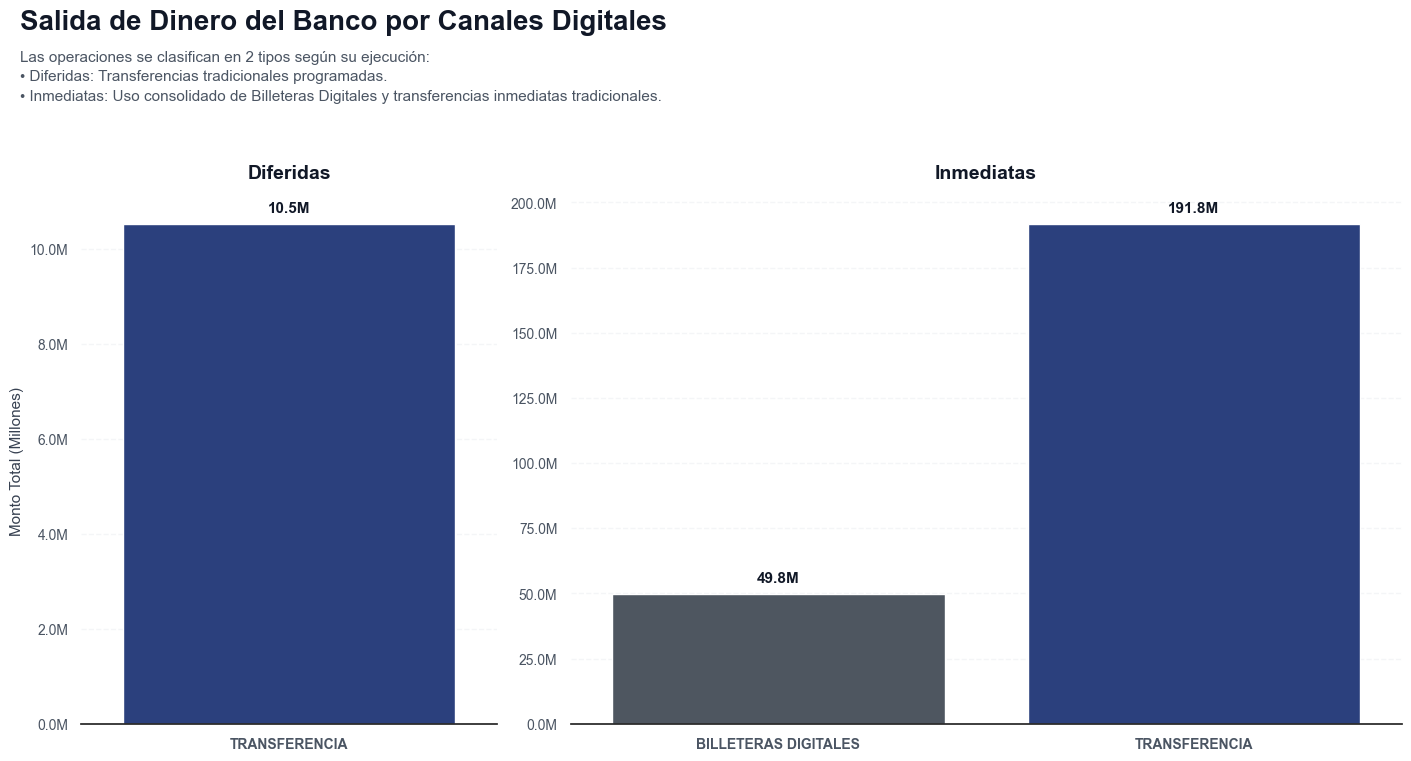

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustamos el estilo visual base limpio e institucional
sns.set_theme(style="white")

# 1. Limpieza y Homologación de datos a mayúsculas
df_consolidado['INTEROP. QR'] = df_consolidado['INTEROP. QR'].str.upper().str.strip()

# Agrupación solicitada por tu jefe
df_consolidado['INTEROP. QR'] = df_consolidado['INTEROP. QR'].replace({
    "ENVIO CONTACTO": "BILLETERAS DIGITALES",
    "ENVIO QR": "BILLETERAS DIGITALES"
})

# 2. Volver a agrupar los datos para sumar las billeteras consolidadas
df_grafico = df_consolidado.groupby(['Tipo', 'INTEROP. QR'], as_index=False)['IMPORTE TRANSFERENCIA'].sum()
df_grafico['IMPORTE_MILLONES'] = df_grafico['IMPORTE TRANSFERENCIA'] / 1_000_000
df_filtrado = df_grafico[df_grafico['Tipo'].isin(['Diferidas', 'Inmediatas'])]

# Paleta corporativa premium adaptada a las nuevas categorías consolidadas
colores_ejecutivos = {
    "TRANSFERENCIA": "#1E3A8A",         # Azul Marino Institucional
    "BILLETERAS DIGITALES": "#4B5563"    # Gris Grafito Ejecutivo
}

# 3. Configurar la figura (usamos width_ratios dinámicos automáticos según las barras reales)
# Como Diferidas tiene 1 categoría e Inmediatas tiene 2, el ratio [1, 2] es la clave visual
fig, axes = plt.subplots(
    1, 2, 
    figsize=(14, 7.5), 
    gridspec_kw={'width_ratios': [1, 2]},
    constrained_layout=True
)

# --- Gráfico 1: Diferidas (Sin forzar orden para que la barra se centre sola) ---
df_dif = df_filtrado[df_filtrado['Tipo'] == 'Diferidas']
sns.barplot(
    data=df_dif, x='INTEROP. QR', y='IMPORTE_MILLONES',
    palette=colores_ejecutivos, ax=axes[0], hue='INTEROP. QR', legend=False
)
axes[0].set_title("Diferidas", fontsize=14, weight='bold', color='#111827', pad=15)

# --- Gráfico 2: Inmediatas (Sin forzar orden para que use sus datos reales) ---
df_inm = df_filtrado[df_filtrado['Tipo'] == 'Inmediatas']
sns.barplot(
    data=df_inm, x='INTEROP. QR', y='IMPORTE_MILLONES',
    palette=colores_ejecutivos, ax=axes[1], hue='INTEROP. QR', legend=False
)
axes[1].set_title("Inmediatas", fontsize=14, weight='bold', color='#111827', pad=15)

# 4. Estilizado corporativo de los subplots
for i, ax in enumerate(axes):
    # Formateo de números elegante en el eje Y
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.1f}M"))
    ax.tick_params(colors='#4B5563', labelsize=10)
    
    # El eje Y solo se etiqueta en el primer gráfico para una estética limpia
    ax.set_ylabel("Monto Total (Millones)" if i == 0 else "", fontsize=11, color='#374151')
    ax.set_xlabel("", fontsize=11)
    
    # Etiquetas del eje X totalmente rectas y ordenadas
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, weight='semibold', color='#4B5563', fontsize=10)
    
    # Cuadrícula horizontal sutil
    ax.grid(axis='y', linestyle='--', alpha=0.4, color='#E5E7EB')
    sns.despine(ax=ax, left=True, bottom=False)
    
    # Etiquetas numéricas exactas sobre cada barra existente
    for container in ax.containers:
        ax.bar_label(
            container, 
            fmt='%.1fM', 
            padding=6, 
            fontsize=11, 
            weight='bold',
            color='#111827'
        )

# 5. Distribución de Títulos y Textos (Mantenemos el aire de la cabecera ejecutiva)
plt.suptitle(
    "Salida de Dinero del Banco por Canales Digitales", 
    fontsize=20, weight='bold', color='#111827', x=0.01, ha='left'
)

subtitulo_texto = (
    "Las operaciones se clasifican en 2 tipos según su ejecución:\n"
    "• Diferidas: Transferencias tradicionales programadas.\n"
    "• Inmediatas: Uso consolidado de Billeteras Digitales y transferencias inmediatas tradicionales."
)
fig.text(0.01, 0.94, subtitulo_texto, fontsize=11, color='#4B5563', ha='left', va='top', linespacing=1.5)

# Separación garantizada del bloque superior
fig.get_layout_engine().set(rect=[0, 0, 1, 0.84])

plt.show()


In [78]:
import pandas as pd
import numpy as np

# =====================================================================
# 1. ESCENARIO A: CÁLCULO DE MÉTRICAS GLOBALES (SIN FILTROS)
# =====================================================================
total_op_global = len(df_consolidado)
monto_global_m = df_consolidado['IMPORTE TRANSFERENCIA'].sum() / 1_000_000
clientes_global = df_consolidado['CODIGO CLIENTE'].nunique()

# Desglose Global por Canal (Tipo)
df_inm_glob = df_consolidado[df_consolidado['Tipo'] == 'Inmediatas']
monto_inm_glob_m = df_inm_glob['IMPORTE TRANSFERENCIA'].sum() / 1_000_000
ticket_inm_glob = df_inm_glob['IMPORTE TRANSFERENCIA'].mean() if len(df_inm_glob) > 0 else 0

df_dif_glob = df_consolidado[df_consolidado['Tipo'] == 'Diferidas']
monto_dif_glob_m = df_dif_glob['IMPORTE TRANSFERENCIA'].sum() / 1_000_000
ticket_dif_glob = df_dif_glob['IMPORTE TRANSFERENCIA'].mean() if len(df_dif_glob) > 0 else 0

# Desglose Global por Origen (INTEROP. QR) ordenado de mayor a menor
df_interop_monto = (df_consolidado.groupby('INTEROP. QR')['IMPORTE TRANSFERENCIA'].sum().sort_values(ascending=False) / 1_000_000)

# =====================================================================
# 2. ESCENARIO B: ZOOM DE ENFOQUE (SÓLO CATEGORÍA "OTROS")
# =====================================================================
# Filtramos la raíz del problema identificada por tu jefa
df_otros = df_consolidado[df_consolidado['INTEROP. QR'] == 'TRANSFERENCIA']

total_op_otros = len(df_otros)
monto_otros_m = df_otros['IMPORTE TRANSFERENCIA'].sum() / 1_000_000
clientes_otros = df_otros['CODIGO CLIENTE'].nunique()

# Desglose interno de "Otros" por Tipo de Canal
df_inm_otros = df_otros[df_otros['Tipo'] == 'Inmediatas']
tx_inm_otros = len(df_inm_otros)
monto_inm_otros = df_inm_otros['IMPORTE TRANSFERENCIA'].sum()
monto_inm_otros_m = monto_inm_otros / 1_000_000
ticket_inm_otros = df_inm_otros['IMPORTE TRANSFERENCIA'].mean() if tx_inm_otros > 0 else 0

# --- Métricas por cliente para Inmediatas ---
clientes_inm_otros = df_inm_otros['CODIGO CLIENTE'].nunique()
monto_por_cliente_inm = (monto_inm_otros / clientes_inm_otros) if clientes_inm_otros > 0 else 0
# NUEVO: Promedio de operaciones transaccionadas por usuario
ops_por_cliente_inm = (tx_inm_otros / clientes_inm_otros) if clientes_inm_otros > 0 else 0


df_dif_otros = df_otros[df_otros['Tipo'] == 'Diferidas']
tx_dif_otros = len(df_dif_otros)
monto_dif_otros = df_dif_otros['IMPORTE TRANSFERENCIA'].sum()
monto_dif_otros_m = monto_dif_otros / 1_000_000
ticket_dif_otros = df_dif_otros['IMPORTE TRANSFERENCIA'].mean() if tx_dif_otros > 0 else 0

# --- Métricas por cliente para Diferidas ---
clientes_dif_otros = df_dif_otros['CODIGO CLIENTE'].nunique()
monto_por_cliente_dif = (monto_dif_otros / clientes_dif_otros) if clientes_dif_otros > 0 else 0
# NUEVO: Promedio de operaciones transaccionadas por usuario
ops_por_cliente_dif = (tx_dif_otros / clientes_dif_otros) if clientes_dif_otros > 0 else 0


# Cálculo del porcentaje de participación de 'Otros' frente al total general
porcentaje_otros_global = (monto_otros_m / monto_global_m) * 100 if monto_global_m > 0 else 0


# =====================================================================
# 3. IMPRESIÓN DEL DASHBOARD ESTRATÉGICO DE NEGOCIO
# =====================================================================
print("=" * 85)
print(" 📊  DASHBOARD ESTRATÉGICO - HISTORIA DE EXPOSICIÓN Y FUGA (JUNIO)")
print("=" * 85)

# --- Bloque General ---
print(f" 🌐 1. PANORAMA GENERAL (Sin Filtros):")
print(f"    • Monto Total de Salida  : S/ {monto_global_m:,.2f} Millones de PEN")
print(f"    • Clientes Únicos Activos : {clientes_global:,} Usuarios")
print(f"    • Ticket Promedio CCE     : Inmediatas S/ {ticket_inm_glob:,.2f} | Diferidas S/ {ticket_dif_glob:,.2f}")
print(f"\n    🔍 PARTICIPACIÓN POR ORIGEN (INTEROP. QR):")

# Listado dinámico de la tajada de dinero que se lleva cada categoría de INTEROP. QR
for categoria, monto_cat in df_interop_monto.items():
    porcentaje_cat = (monto_cat / monto_global_m) * 100 if monto_global_m > 0 else 0
    indicador = "🚨" if categoria == "Otros" else "▪️"
    print(f"      {indicador} {categoria:<18}: S/ {monto_cat:,.2f}M ({porcentaje_cat:.1f}%)")

print("-" * 85)

# --- Bloque de Concentración ("Otros") ---
print(f" 🎯 2. ZOOM AL FOCO DE ALTO VALOR (Sólo Categoría 'Otros'):")
print(f"    • Monto Concentrado Aquí  : S/ {monto_otros_m:,.2f}M ({porcentaje_otros_global:.1f}% del total global)")
print(f"    • Clientes Involucrados   : {clientes_otros:,} Usuarios")
print(f"    • Operaciones Ejecutadas  : {total_op_otros:,} Transacciones")
print("-" * 85)

# --- Desglose Interno del Comportamiento Técnico ---
print(f"    ⚡ COMPORTAMIENTO DE LOS GRANDES MONTOS EN 'OTROS':")
print(f"    🟦 Transferencias Inmediatas:")
print(f"       • Monto Fugado     : S/ {monto_inm_otros_m:,.2f}M ({(monto_inm_otros_m / monto_otros_m)*100:.1f}%)")
print(f"       • Ticket Promedio  : S/ {ticket_inm_otros:,.2f} PEN")
print(f"       • Promedio por Cliente: S/ {monto_por_cliente_inm:,.2f} PEN")
print(f"       • Operaciones por Cliente: {ops_por_cliente_inm:,.1f} transacciones") # <--- NUEVO
print(f"    🟧 Transferencias Diferidas:")
print(f"       • Monto Fugado     : S/ {monto_dif_otros_m:,.2f}M ({(monto_dif_otros_m / monto_otros_m)*100:.1f}%)")
print(f"       • Ticket Promedio  : S/ {ticket_dif_otros:,.2f} PEN")
print(f"       • Promedio por Cliente: S/ {monto_por_cliente_dif:,.2f} PEN")
print(f"       • Operaciones por Cliente: {ops_por_cliente_dif:,.1f} transacciones") # <--- NUEVO
print("=" * 85)

# --- Discurso de Negocio Integrado para la Presentación ---
print("💡 Discurso para la Jefa (Apertura de la Mesa de Trabajo):")
print(f"\"Para iniciar la sesión, pongamos el problema en dimensión: Durante el mes de junio, la App experimentó")
print(f" una salida global de S/ {monto_global_m:,.2f}M. Sin embargo, nuestro análisis de riesgo detectó que")
print(f" el verdadero peligro no está distribuido equitativamente, sino concentrado críticamente en la categoría 'Otros',")
print(f" la cual absorbe por sí sola S/ {monto_otros_m:,.2f}M —es decir, el {porcentaje_otros_global:.1f}% de toda la fuga del banco—. \"\n")

print(f"\"Al abrir la caja de 'Otros', confirmamos la hipótesis de que aquí se orquestan los movimientos más agresivos:")
print(f" mientras que las transferencias inmediatas de este grupo registran un promedio de {ops_por_cliente_inm:,.1f} operaciones por cliente, moviendo un ticket promedio transaccional de S/ {ticket_inm_otros:,.2f} (lo que equivale a S/ {monto_por_cliente_inm:,.2f} en total por usuario),\"") # <--- ACTUALIZADO
print(f"\"las operaciones diferidas muestran un comportamiento mucho más enfocado. En este canal, cada cliente ejecuta un promedio de {ops_por_cliente_dif:,.1f} transacciones en el mes, pero con una contundencia alarmante: el ticket por transacción se dispara a S/ {ticket_dif_otros:,.2f}, logrando extraer un promedio acumulado de S/ {monto_por_cliente_dif:,.2f} PEN por cliente.\"") # <--- ACTUALIZADO
print(f"\n\"Este comportamiento de alta concentración —pocas operaciones pero de montos críticos por cliente— confirma un patrón de vaciado intencional de cuentas de ahorros de alto valor mediante operaciones diferidas programadas, y sobre este segmento es donde ejecutaremos las medidas de contención.\"")
print("=" * 85)


 📊  DASHBOARD ESTRATÉGICO - HISTORIA DE EXPOSICIÓN Y FUGA (JUNIO)
 🌐 1. PANORAMA GENERAL (Sin Filtros):
    • Monto Total de Salida  : S/ 252.15 Millones de PEN
    • Clientes Únicos Activos : 59,108 Usuarios
    • Ticket Promedio CCE     : Inmediatas S/ 336.24 | Diferidas S/ 3,621.61

    🔍 PARTICIPACIÓN POR ORIGEN (INTEROP. QR):
      ▪️ TRANSFERENCIA     : S/ 202.35M (80.2%)
      ▪️ BILLETERAS DIGITALES: S/ 49.80M (19.8%)
-------------------------------------------------------------------------------------
 🎯 2. ZOOM AL FOCO DE ALTO VALOR (Sólo Categoría 'Otros'):
    • Monto Concentrado Aquí  : S/ 202.35M (80.2% del total global)
    • Clientes Involucrados   : 34,208 Usuarios
    • Operaciones Ejecutadas  : 284,770 Transacciones
-------------------------------------------------------------------------------------
    ⚡ COMPORTAMIENTO DE LOS GRANDES MONTOS EN 'OTROS':
    🟦 Transferencias Inmediatas:
       • Monto Fugado     : S/ 191.82M (94.8%)
       • Ticket Promedio  : S/ 680

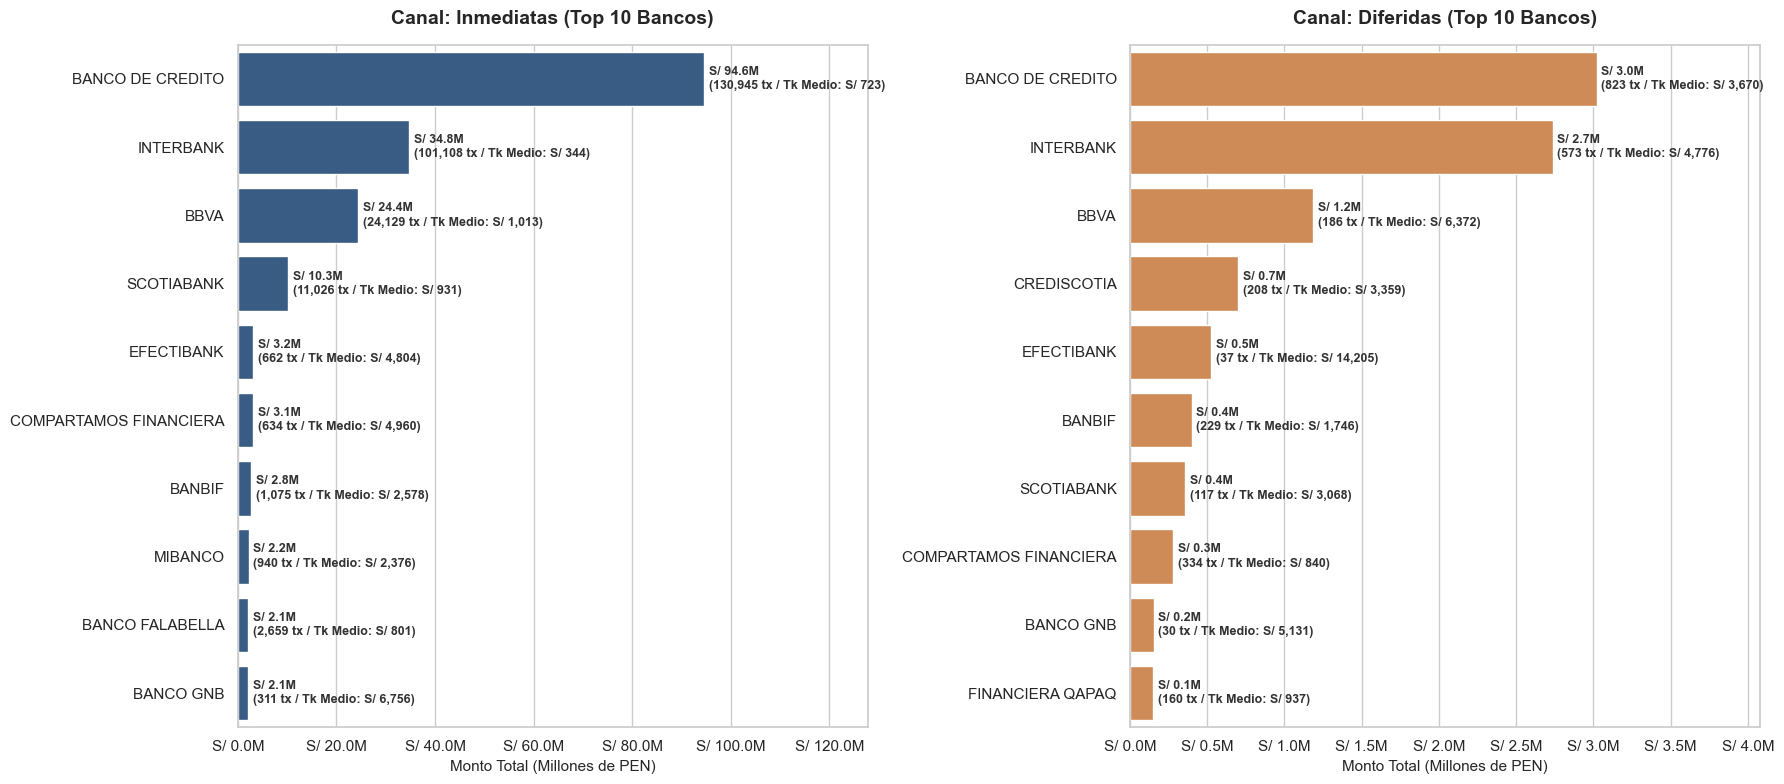

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar datos por Entidad y Tipo calculando Suma, Conteo (Operaciones) y Media (Ticket Promedio)
df_entidades = df_otros.groupby(['NOMBRE ENTIDAD DESTINO', 'Tipo']).agg(
    Monto_Total=('IMPORTE TRANSFERENCIA', 'sum'),
    Operaciones=('IMPORTE TRANSFERENCIA', 'count'),
    Ticket_Medio=('IMPORTE TRANSFERENCIA', 'mean')
).reset_index()

df_entidades['MONTO_MILLONES'] = df_entidades['Monto_Total'] / 1_000_000

# 2. Filtrar el Top 10 de entidades para cada canal de manera independiente
top_inmediatas = df_entidades[df_entidades['Tipo'] == 'Inmediatas'].nlargest(10, 'Monto_Total')
top_diferidas = df_entidades[df_entidades['Tipo'] == 'Diferidas'].nlargest(10, 'Monto_Total')

# 3. Configurar el estilo de Seaborn
sns.set_theme(style="whitegrid")

# Crear la figura manualmente con subplots para controlar dinámicamente las etiquetas de texto
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

# --- PANEL 1: INMEDIATAS ---
sns.barplot(
    data=top_inmediatas, y='NOMBRE ENTIDAD DESTINO', x='MONTO_MILLONES',
    ax=ax1, color='#2b5c8f'
)
ax1.set_title("Canal: Inmediatas (Top 10 Bancos)", fontsize=14, weight='bold', pad=15)
ax1.set_xlabel("Monto Total (Millones de PEN)", fontsize=11)
ax1.set_ylabel("")
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"S/ {x:,.1f}M"))

# Inyectar métricas en las barras de Inmediatas
for i, (idx, fila) in enumerate(top_inmediatas.iterrows()):
    texto_metrica = f"S/ {fila['MONTO_MILLONES']:.1f}M\n({int(fila['Operaciones']):,} tx / Tk Medio: S/ {fila['Ticket_Medio']:,.0f})"
    ax1.text(
        fila['MONTO_MILLONES'] + (top_inmediatas['MONTO_MILLONES'].max() * 0.01), 
        i, texto_metrica, 
        va='center', fontsize=9, weight='semibold', color='#333333'
    )

# --- PANEL 2: DIFERIDAS ---
sns.barplot(
    data=top_diferidas, y='NOMBRE ENTIDAD DESTINO', x='MONTO_MILLONES',
    ax=ax2, color='#e28743'
)
ax2.set_title("Canal: Diferidas (Top 10 Bancos)", fontsize=14, weight='bold', pad=15)
ax2.set_xlabel("Monto Total (Millones de PEN)", fontsize=11)
ax2.set_ylabel("")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"S/ {x:,.1f}M"))

# Inyectar métricas en las barras de Diferidas
for i, (idx, fila) in enumerate(top_diferidas.iterrows()):
    texto_metrica = f"S/ {fila['MONTO_MILLONES']:.1f}M\n({int(fila['Operaciones']):,} tx / Tk Medio: S/ {fila['Ticket_Medio']:,.0f})"
    ax2.text(
        fila['MONTO_MILLONES'] + (top_diferidas['MONTO_MILLONES'].max() * 0.01), 
        i, texto_metrica, 
        va='center', fontsize=9, weight='semibold', color='#333333'
    )

# 4. Ajustes finales de márgenes para que no se corten los textos extensos
# Damos holgura extra en los ejes X para que los textos de las etiquetas queden holgados
ax1.set_xlim(0, top_inmediatas['MONTO_MILLONES'].max() * 1.35)
ax2.set_xlim(0, top_diferidas['MONTO_MILLONES'].max() * 1.35)

plt.tight_layout()
plt.show()


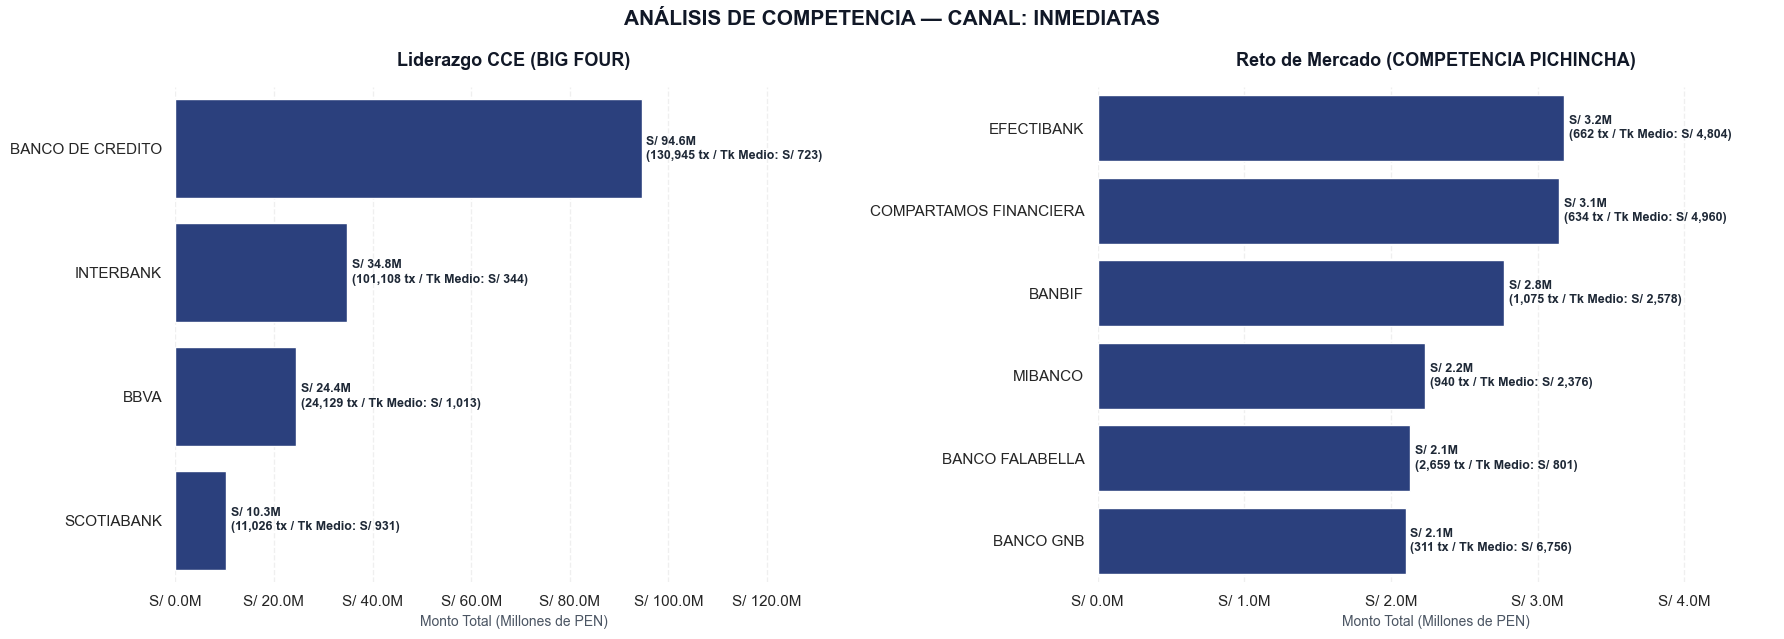

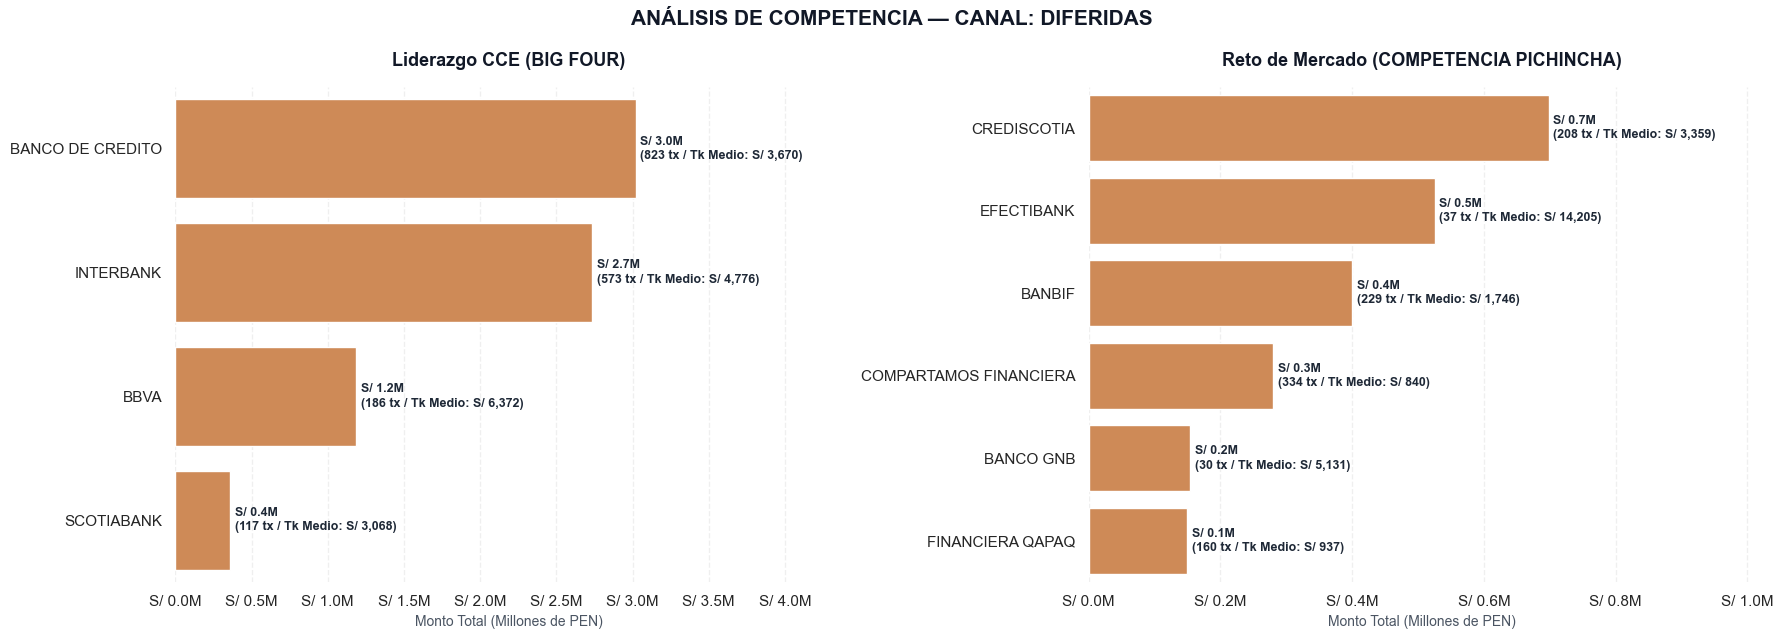

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustamos el estilo visual de alta gama plano
sns.set_theme(style="white")

# Colores institucionales para mantener consistencia de canal
color_inmediatas = "#1E3A8A"  # Azul Marino
color_diferidas = "#E28743"   # Ámbar/Naranja Ejecutivo

# =====================================================================
# 1. PREPARACIÓN Y FILTRADO POR GRUPOS INDEPENDIENTES
# =====================================================================
df_inm = df_entidades[df_entidades['Tipo'] == 'Inmediatas']
df_dif = df_entidades[df_entidades['Tipo'] == 'Diferidas']

# Segmentación para Canal Inmediatas
inm_big_four = df_inm[df_inm['GRUPO_COMPETENCIA'] == 'BIG FOUR'].nlargest(4, 'MONTO_MILLONES').reset_index(drop=True)
inm_pichincha = df_inm[df_inm['GRUPO_COMPETENCIA'] == 'COMPETENCIA PICHINCHA'].nlargest(6, 'MONTO_MILLONES').reset_index(drop=True)

# Segmentación para Canal Diferidas
dif_big_four = df_dif[df_dif['GRUPO_COMPETENCIA'] == 'BIG FOUR'].nlargest(4, 'MONTO_MILLONES').reset_index(drop=True)
dif_pichincha = df_dif[df_dif['GRUPO_COMPETENCIA'] == 'COMPETENCIA PICHINCHA'].nlargest(6, 'MONTO_MILLONES').reset_index(drop=True)

# =====================================================================
# 2. FUNCIÓN AUXILIAR PARA INYECTAR LAS ETIQUETAS INTERNAS
# =====================================================================
def agregar_etiquetas_barras(df, ax):
    for i, fila in df.iterrows():
        texto_metrica = f"S/ {fila['MONTO_MILLONES']:.1f}M\n({int(fila['Operaciones']):,} tx / Tk Medio: S/ {fila['Ticket_Medio']:,.0f})"
        ax.text(
            fila['MONTO_MILLONES'] + (df['MONTO_MILLONES'].max() * 0.01), 
            i, texto_metrica, 
            va='center', fontsize=9, weight='bold', color='#1F2937'
        )
    ax.set_xlim(0, df['MONTO_MILLONES'].max() * 1.45) # Aire para que entre el texto

# =====================================================================
# 3. FILA 1: CANAL INMEDIATAS (2 Columnas Separadas)
# =====================================================================
fig1, (ax1_l, ax1_r) = plt.subplots(1, 2, figsize=(18, 6.5))

# Subpanel Izquierdo: Big Four
sns.barplot(data=inm_big_four, y='NOMBRE ENTIDAD DESTINO', x='MONTO_MILLONES', color=color_inmediatas, ax=ax1_l)
ax1_l.set_title("Liderazgo CCE (BIG FOUR)", fontsize=13, weight='bold', pad=15, color='#111827')
ax1_l.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"S/ {x:,.1f}M"))
ax1_l.set_xlabel("Monto Total (Millones de PEN)", fontsize=10, color='#4B5563')
ax1_l.set_ylabel("")
ax1_l.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine(ax=ax1_l, left=True, bottom=True)
agregar_etiquetas_barras(inm_big_four, ax1_l)

# Subpanel Derecho: Competencia Pichincha
sns.barplot(data=inm_pichincha, y='NOMBRE ENTIDAD DESTINO', x='MONTO_MILLONES', color=color_inmediatas, ax=ax1_r)
ax1_r.set_title("Reto de Mercado (COMPETENCIA PICHINCHA)", fontsize=13, weight='bold', pad=15, color='#111827')
ax1_r.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"S/ {x:,.1f}M"))
ax1_r.set_xlabel("Monto Total (Millones de PEN)", fontsize=10, color='#4B5563')
ax1_r.set_ylabel("")
ax1_r.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine(ax=ax1_r, left=True, bottom=True)
agregar_etiquetas_barras(inm_pichincha, ax1_r)

fig1.suptitle("ANÁLISIS DE COMPETENCIA — CANAL: INMEDIATAS", fontsize=15, weight='bold', color='#111827', y=0.98)
plt.tight_layout()
plt.show()

# =====================================================================
# 4. FILA 2: CANAL DIFERIDAS (2 Columnas Separadas)
# =====================================================================
fig2, (ax2_l, ax2_r) = plt.subplots(1, 2, figsize=(18, 6.5))

# Subpanel Izquierdo: Big Four
sns.barplot(data=dif_big_four, y='NOMBRE ENTIDAD DESTINO', x='MONTO_MILLONES', color=color_diferidas, ax=ax2_l)
ax2_l.set_title("Liderazgo CCE (BIG FOUR)", fontsize=13, weight='bold', pad=15, color='#111827')
ax2_l.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"S/ {x:,.1f}M"))
ax2_l.set_xlabel("Monto Total (Millones de PEN)", fontsize=10, color='#4B5563')
ax2_l.set_ylabel("")
ax2_l.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine(ax=ax2_l, left=True, bottom=True)
agregar_etiquetas_barras(dif_big_four, ax2_l)

# Subpanel Derecho: Competencia Pichincha
sns.barplot(data=dif_pichincha, y='NOMBRE ENTIDAD DESTINO', x='MONTO_MILLONES', color=color_diferidas, ax=ax2_r)
ax2_r.set_title("Reto de Mercado (COMPETENCIA PICHINCHA)", fontsize=13, weight='bold', pad=15, color='#111827')
ax2_r.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"S/ {x:,.1f}M"))
ax2_r.set_xlabel("Monto Total (Millones de PEN)", fontsize=10, color='#4B5563')
ax2_r.set_ylabel("")
ax2_r.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine(ax=ax2_r, left=True, bottom=True)
agregar_etiquetas_barras(dif_pichincha, ax2_r)

fig2.suptitle("ANÁLISIS DE COMPETENCIA — CANAL: DIFERIDAS", fontsize=15, weight='bold', color='#111827', y=0.98)
plt.tight_layout()
plt.show()


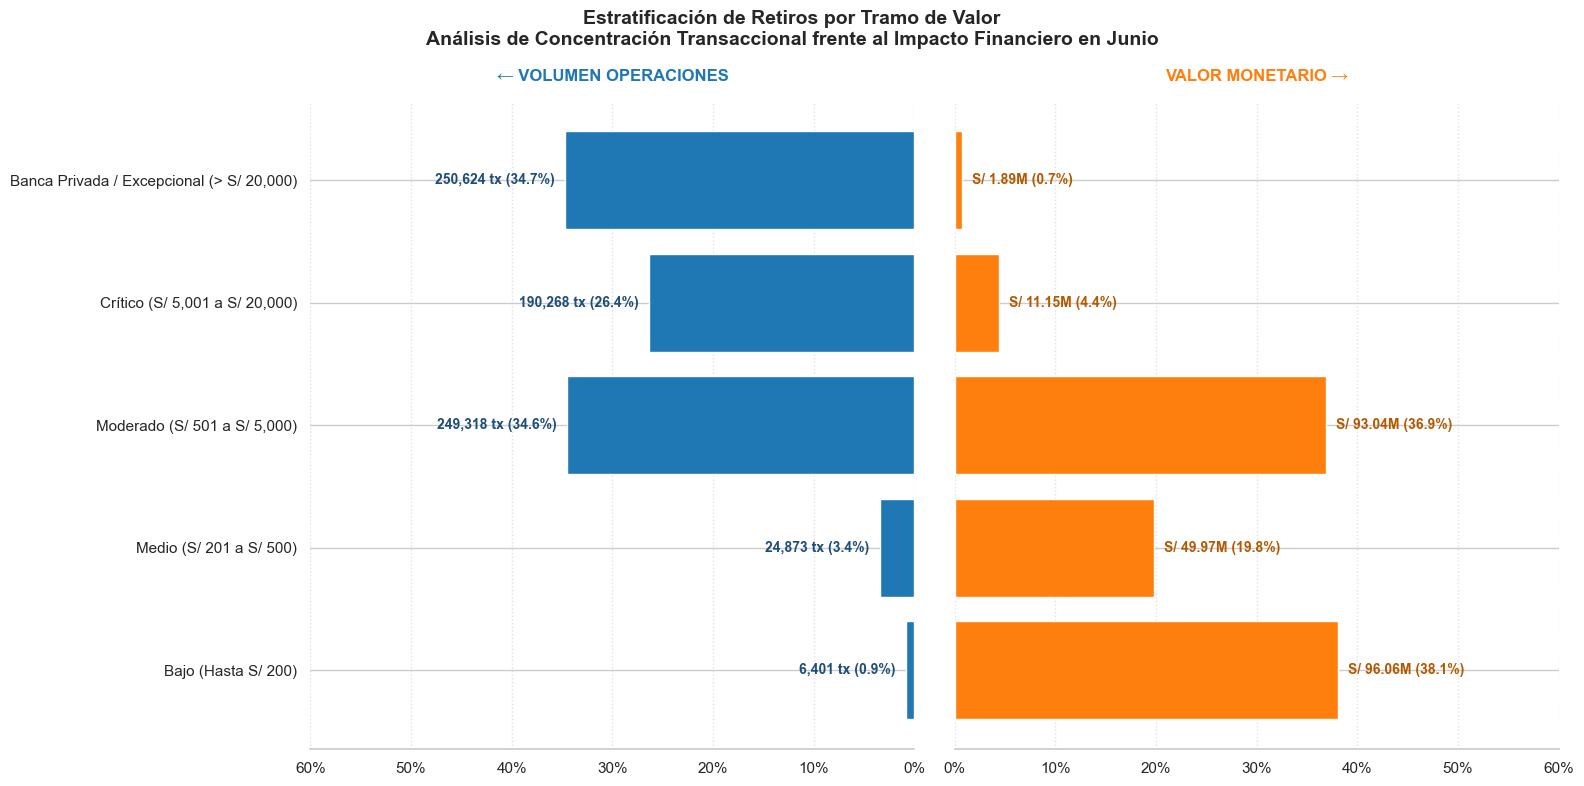

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
## Modificar -----------------
# =====================================================================
# 1. PREPARACIÓN DE DATOS (REPLICA LOS DATOS DE TU ANÁLISIS)
# =====================================================================
# Definimos las etiquetas de los 5 tramos (en orden inverso para que el más alto salga arriba)
categorias = [
    'Banca Privada / Excepcional (> S/ 20,000)',
    'Crítico (S/ 5,001 a S/ 20,000)',
    'Moderado (S/ 501 a S/ 5,000)',
    'Medio (S/ 201 a S/ 500)',
    'Bajo (Hasta S/ 200)'
][::-1] # Invertimos el orden para el eje Y

# --- REEMPLAZA ESTOS VALORES CON LOS QUE TE SALIERON EN LA CONSOLA ---
# Ejemplo de transacciones por tramo
tx_valores = [250624, 190268, 249318, 24873, 6401][::-1] 
# Ejemplo de montos en millones por tramo
monto_valores = [1.89, 11.15, 93.04, 49.97, 96.06][::-1] 

# Calcular los totales para sacar los porcentajes del eje X
total_tx_global = sum(tx_valores)
total_monto_global = sum(monto_valores)

# Convertir los valores a porcentajes para la longitud de las barras
pct_tx = [(tx / total_tx_global) * 100 for tx in tx_valores]
pct_monto = [(monto / total_monto_global) * 100 for monto in monto_valores]

# =====================================================================
# 2. CONSTRUCCIÓN DEL GRÁFICO DE TORNADO (ESPEJO)
# =====================================================================
fig, axes = plt.subplots(ncols=2, sharey=True, figsize=(16, 8))
plt.subplots_adjust(wspace=0) # Une ambos gráficos en el centro (eje 0)

# Colores institucionales de la imagen
color_azul = '#1f77b4'
color_naranja = '#ff7f0e'

# --- PANEL IZQUIERDO: VOLUMEN DE OPERACIONES (Barras hacia la izquierda) ---
axes[0].barh(categorias, pct_tx, color=color_azul, align='center')
axes[0].set_title('← VOLUMEN OPERACIONES', fontsize=12, weight='bold', color=color_azul, pad=15)
axes[0].set_xlim(60, 0) # Invierte el eje X para que apunte a la izquierda (máximo 60%)

# --- PANEL DERECHO: VALOR MONETARIO (Barras hacia la derecha) ---
axes[1].barh(categorias, pct_monto, color=color_naranja, align='center')
axes[1].set_title('VALOR MONETARIO →', fontsize=12, weight='bold', color=color_naranja, pad=15)
axes[1].set_xlim(0, 60) # Eje X estándar (máximo 60%)

# =====================================================================
# 3. AGREGAR ETIQUETAS DE TEXTO DETALLADAS (MÉTRICA + PORCENTAJE)
# =====================================================================
# Formatear ejes X con el símbolo de porcentaje
for ax in axes:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)}%"))
    ax.grid(axis='x', linestyle=':', alpha=0.6)

# Etiquetas en las barras azules (Izquierda)
for i, (pct, tx) in enumerate(zip(pct_tx, tx_valores)):
    texto = f"{tx:,} tx ({pct:.1f}%)"
    axes[0].text(pct + 1, i, texto, va='center', ha='right', fontsize=10, color='#1f4e79', weight='semibold')

# Etiquetas en las barras naranjas (Derecha)
for i, (pct, monto) in enumerate(zip(pct_monto, monto_valores)):
    texto = f"S/ {monto:,.2f}M ({pct:.1f}%)"
    axes[1].text(pct + 1, i, texto, va='center', ha='left', fontsize=10, color='#b35900', weight='semibold')

# =====================================================================
# 4. TÍTULOS Y AJUSTES FINALES
# =====================================================================
plt.suptitle(
    'Estratificación de Retiros por Tramo de Valor\n'
    'Análisis de Concentración Transaccional frente al Impacto Financiero en Junio',
    fontsize=14, weight='bold', y=0.98
)

# Limpiar bordes innecesarios para un estilo plano y moderno
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()


In [95]:
import pandas as pd
import numpy as np

# =====================================================================
# 1. CONSOLIDACIÓN DE LOS NUEVOS RANGOS SOLICITADOS POR TU JEFE
# =====================================================================
# Ajustamos los límites: el primero junta todo desde el inicio hasta 500
nuevos_limites = [-np.inf, 500, 5000, 20000, np.inf]

# Definimos el nuevo orden lógico oficial (X)
nuevos_tramos = [
    'Menos de S/ 500',                # <--- NUEVO TRAMO CONSOLIDADO
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

# Reclasificamos la data en df_otros con la nueva instrucción
df_otros['RANGO_MONTO_OFICIAL'] = pd.cut(
    df_otros['IMPORTE TRANSFERENCIA'], 
    bins=nuevos_limites, 
    labels=nuevos_tramos
)

# Aseguramos que Pandas respete el orden categórico ejecutivo
df_otros['RANGO_MONTO_OFICIAL'] = pd.Categorical(
    df_otros['RANGO_MONTO_OFICIAL'], 
    categories=nuevos_tramos, 
    ordered=True
)

# =====================================================================
# 2. CONSTRUCCIÓN DE LA NUEVA MATRIZ DE CONSUMO POR CLIENTE Y BANCO
# =====================================================================
tabla_consolidada = df_otros.pivot_table(
    index=['CODIGO CLIENTE', 'NOMBRE ENTIDAD DESTINO'],
    columns='RANGO_MONTO_OFICIAL',
    values='IMPORTE TRANSFERENCIA',
    aggfunc='sum',          # Suma los montos transaccionados en cada tramo
    fill_value=0            # Rellena con 0 si no hay operaciones en ese cruce
).reset_index()

# =====================================================================
# 3. CONTROL DE TOTALES Y ORDENAMIENTO DE EXPOSICIÓN
# =====================================================================
# Calculamos el total general que ese cliente envió a ese banco específico
tabla_consolidada['TOTAL_CONSUMIDO_BANCO'] = tabla_consolidada[nuevos_tramos].sum(axis=1)

# Ordenamos de mayor a menor para identificar primero a las cuentas más agresivas
tabla_consolidada = tabla_consolidada.sort_values(by='TOTAL_CONSUMIDO_BANCO', ascending=False).reset_index(drop=True)

# =====================================================================
# 4. VISTA PREVIA DEL NUEVO REPORTE EJECUTIVO
# =====================================================================
print("📊 NUEVA MATRIZ CONSOLIDADA POR CLIENTE, BANCO Y RANGOS REESTRUCTURADOS")
print(f"Total de registros Cliente-Banco procesados: {len(tabla_consolidada):,}")
print("-" * 115)
print(tabla_consolidada.head(10).to_string(index=False))


📊 NUEVA MATRIZ CONSOLIDADA POR CLIENTE, BANCO Y RANGOS REESTRUCTURADOS
Total de registros Cliente-Banco procesados: 1,094,656
-------------------------------------------------------------------------------------------------------------------
 CODIGO CLIENTE NOMBRE ENTIDAD DESTINO  Menos de S/ 500  Moderado (S/ 501 - S/ 5,000)  Alto (S/ 5,001 - S/ 20,000)  Crítico (Más de S/ 20,000)  TOTAL_CONSUMIDO_BANCO
        3513404       BANCO DE CREDITO              0.0                        6000.0                     15000.00                   419899.00              440899.00
         176316       BANCO DE CREDITO            506.5                        3300.0                    371500.00                        0.00              375306.50
        4182119       BANCO DE CREDITO              0.0                        5000.0                    106000.00                   215000.00              326000.00
        4035567              INTERBANK              0.0                           0.0         

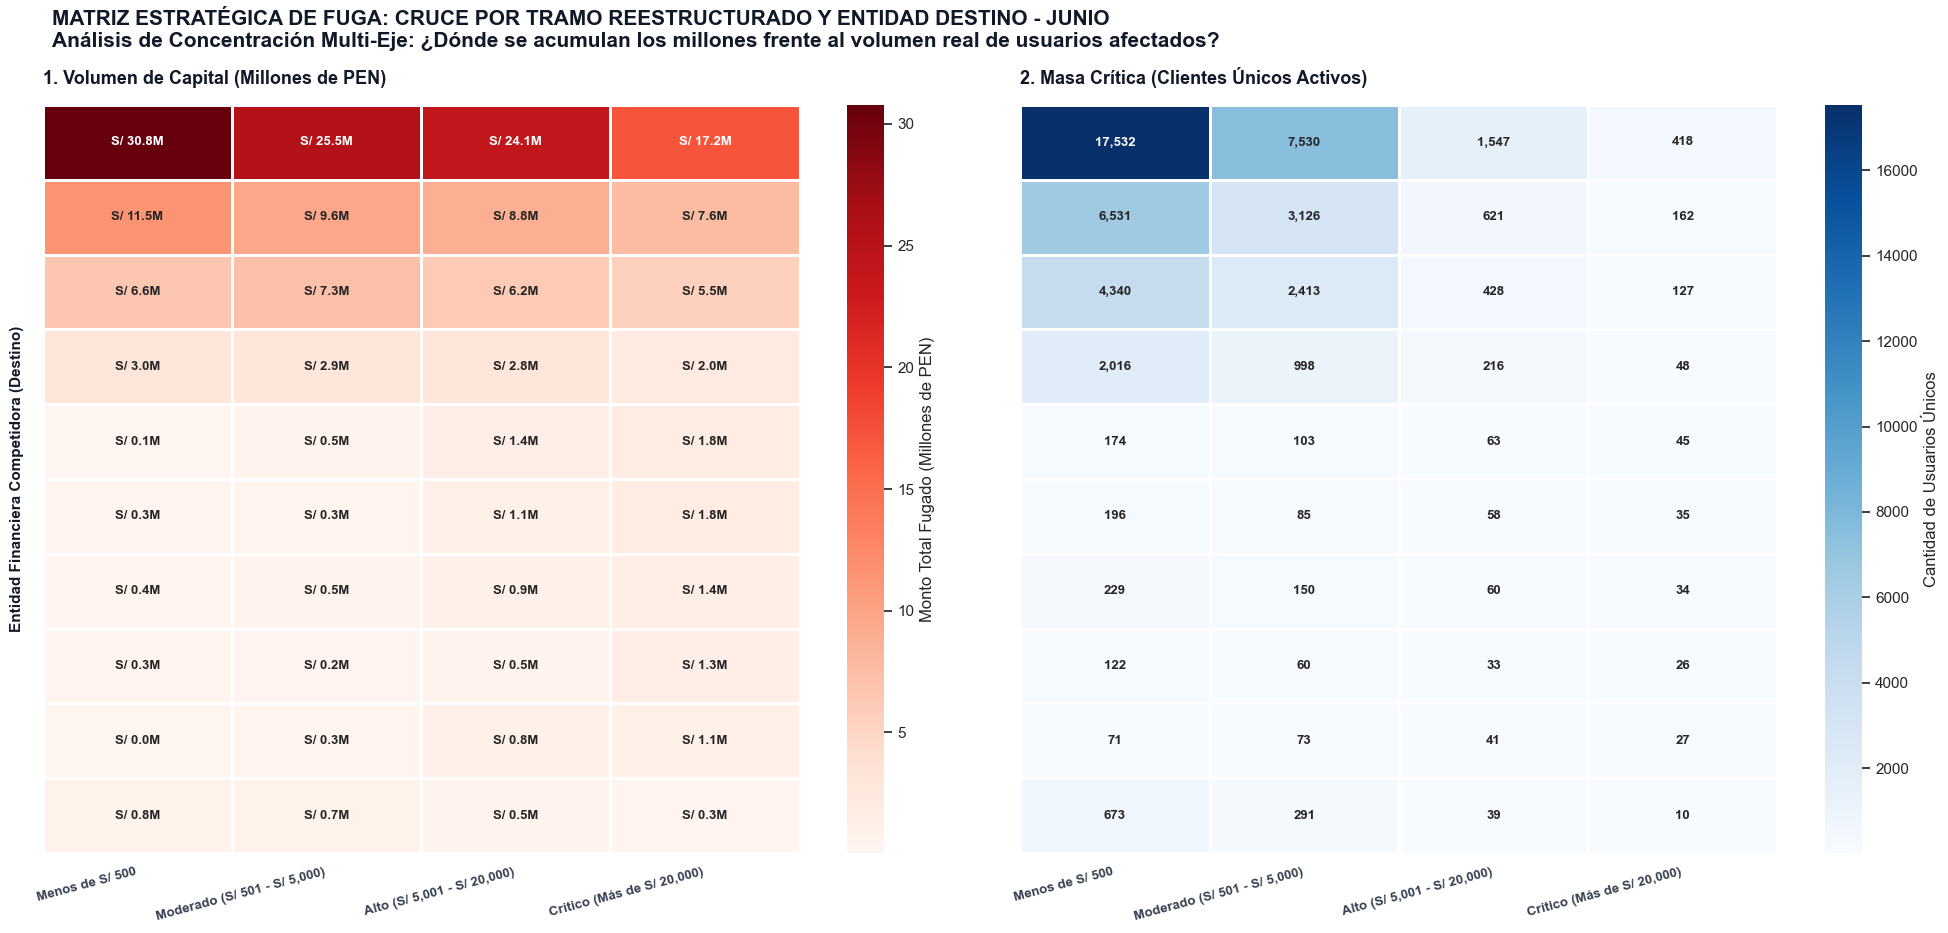

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustamos el estilo visual base premium plano
sns.set_theme(style="white")

# =====================================================================
# 1. PREPARACIÓN DE LAS MATRICES DESDE TU DATAFRAME RAÍZ (df_otros)
# =====================================================================
# Definimos el orden estricto de las nuevas columnas solicitadas por tu jefe
nuevos_tramos = [
    'Menos de S/ 500',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

# Identificamos el Top 10 de bancos destino por monto acumulado para enfocar el análisis
top_10_bancos = (
    df_otros.groupby('NOMBRE ENTIDAD DESTINO')['IMPORTE TRANSFERENCIA']
    .sum()
    .nlargest(10)
    .index
)
df_filtrado_heatmap = df_otros[df_otros['NOMBRE ENTIDAD DESTINO'].isin(top_10_bancos)]

# --- Matriz 1: Monto Total en Millones (Suma) ---
matriz_montos = df_filtrado_heatmap.pivot_table(
    index='NOMBRE ENTIDAD DESTINO', columns='RANGO_MONTO_OFICIAL',
    values='IMPORTE TRANSFERENCIA', aggfunc='sum', fill_value=0
).reindex(index=top_10_bancos, columns=nuevos_tramos)

matriz_millones = matriz_montos / 1_000_000

# --- Matriz 2: Número de Clientes Únicos (Nunique) ---
matriz_clientes = df_filtrado_heatmap.pivot_table(
    index='NOMBRE ENTIDAD DESTINO', columns='RANGO_MONTO_OFICIAL',
    values='CODIGO CLIENTE', aggfunc='nunique', fill_value=0
).reindex(index=top_10_bancos, columns=nuevos_tramos)

# =====================================================================
# 2. CONSTRUCCIÓN DE LA DOBLE VISTA EJECUTIVA (Monto vs. Volumen de Clientes)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9.5), sharey=True)

# --- PANEL IZQUIERDO: MONTO EN MILLONES ---
sns.heatmap(
    matriz_millones, annot=True, fmt=",.2f", cmap="Reds", 
    linewidths=0.8, ax=ax1, cbar_kws={'label': 'Monto Total Fugado (Millones de PEN)'}
)
ax1.set_title("1. Volumen de Capital (Millones de PEN)", fontsize=13, weight='bold', pad=15, color='#111827', loc='left')
ax1.set_xlabel("", fontsize=11)
ax1.set_ylabel("Entidad Financiera Competidora (Destino)", fontsize=11, weight='bold', color='#111827')

# Dar formato monetario a las etiquetas del panel 1
for text in ax1.texts:
    val = float(text.get_text().replace(',', ''))
    text.set_text(f"S/ {val:,.1f}M" if val > 0 else "-")
    text.set_fontsize(9.5)
    text.set_weight('bold')

# --- PANEL DERECHO: CONTEO DE CLIENTES ÚNICOS ---
sns.heatmap(
    matriz_clientes, annot=True, fmt=",.0f", cmap="Blues", 
    linewidths=0.8, ax=ax2, cbar_kws={'label': 'Cantidad de Usuarios Únicos'}
)
ax2.set_title("2. Masa Crítica (Clientes Únicos Activos)", fontsize=13, weight='bold', pad=15, color='#111827', loc='left')
ax2.set_xlabel("", fontsize=11)
ax2.set_ylabel("")

# Dar formato de conteo o guion limpio al panel 2
for text in ax2.texts:
    val = float(text.get_text().replace(',', ''))
    text.set_text(f"{int(val):,}" if val > 0 else "-")
    text.set_fontsize(9.5)
    text.set_weight('bold')

# =====================================================================
# 3. DISEÑO DE CABECERAS Y ROTACIONES EJECUTIVAS
# =====================================================================
# Configuración y limpieza de ejes para ambos mapas
for ax in [ax1, ax2]:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9.5, weight='semibold', color='#374151')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10, weight='semibold', color='#111827')
    ax.tick_params(left=False, bottom=False)

# Título Corporativo unificado en zona superior libre
fig.suptitle(
    "MATRIZ ESTRATÉGICA DE FUGA: CRUCE POR TRAMO REESTRUCTURADO Y ENTIDAD DESTINO - JUNIO\n"
    "Análisis de Concentración Multi-Eje: ¿Dónde se acumulan los millones frente al volumen real de usuarios afectados?",
    fontsize=15, weight='bold', color='#111827', y=0.98, x=0.03, ha='left'
)

plt.tight_layout()
plt.subplots_adjust(top=0.88) # Espacio para el gran título superior
plt.show()


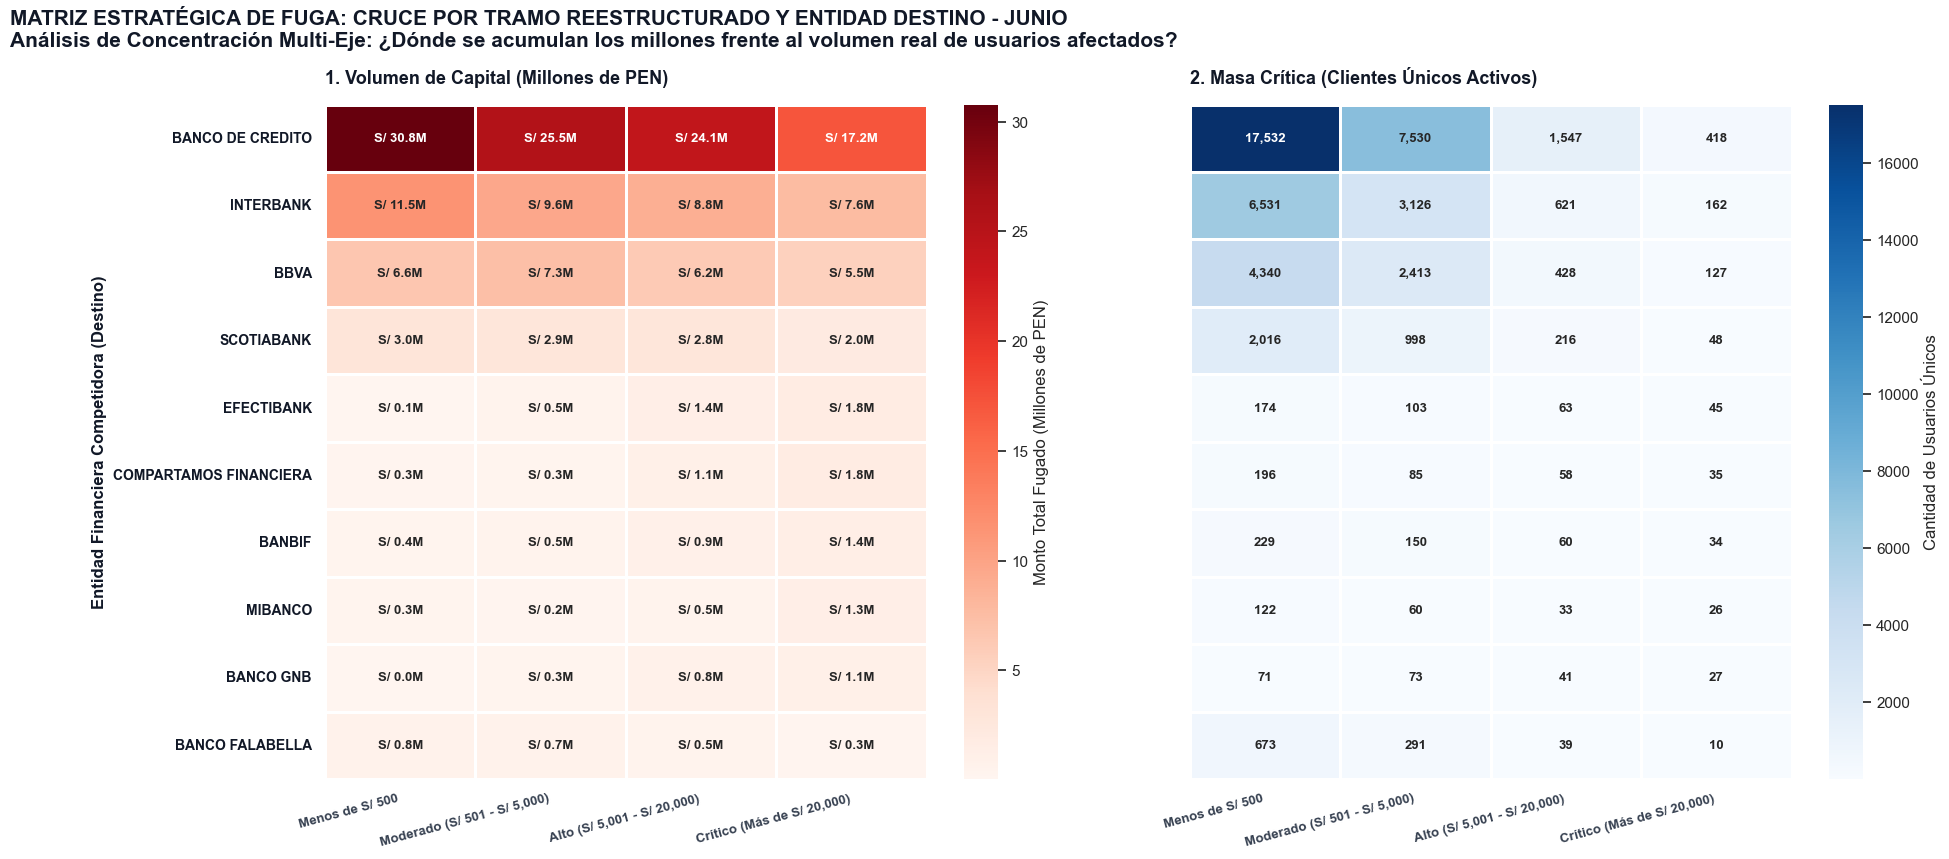

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustamos el estilo visual base premium plano
sns.set_theme(style="white")

# =====================================================================
# 1. PREPARACIÓN DE LAS MATRICES DESDE TU DATAFRAME RAÍZ (df_otros)
# =====================================================================
nuevos_tramos = [
    'Menos de S/ 500',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

# Identificamos el Top 10 de bancos destino por monto acumulado para enfocar el análisis
top_10_bancos = (
    df_otros.groupby('NOMBRE ENTIDAD DESTINO')['IMPORTE TRANSFERENCIA']
    .sum()
    .nlargest(10)
    .index
)
df_filtrado_heatmap = df_otros[df_otros['NOMBRE ENTIDAD DESTINO'].isin(top_10_bancos)]

# --- Matriz 1: Monto Total en Millones (Suma) ---
matriz_montos = df_filtrado_heatmap.pivot_table(
    index='NOMBRE ENTIDAD DESTINO', columns='RANGO_MONTO_OFICIAL',
    values='IMPORTE TRANSFERENCIA', aggfunc='sum', fill_value=0
).reindex(index=top_10_bancos, columns=nuevos_tramos)

matriz_millones = matriz_montos / 1_000_000

# --- Matriz 2: Número de Clientes Únicos (Nunique) ---
matriz_clientes = df_filtrado_heatmap.pivot_table(
    index='NOMBRE ENTIDAD DESTINO', columns='RANGO_MONTO_OFICIAL',
    values='CODIGO CLIENTE', aggfunc='nunique', fill_value=0
).reindex(index=top_10_bancos, columns=nuevos_tramos)

# =====================================================================
# 2. CONSTRUCCIÓN DE LA DOBLE VISTA EJECUTIVA (Monto vs. Volumen de Clientes)
# =====================================================================
# Eliminamos temporalmente constrained_layout para usar subplots_adjust manual preciso
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(21, 9.5), sharey=True)

# --- PANEL IZQUIERDO: MONTO EN MILLONES ---
sns.heatmap(
    matriz_millones, annot=True, fmt=",.2f", cmap="Reds", 
    linewidths=0.8, ax=ax1, cbar_kws={'label': 'Monto Total Fugado (Millones de PEN)'}
)
ax1.set_title("1. Volumen de Capital (Millones de PEN)", fontsize=13, weight='bold', pad=15, color='#111827', loc='left')
ax1.set_xlabel("", fontsize=11)
ax1.set_ylabel("Entidad Financiera Competidora (Destino)", fontsize=12, weight='bold', color='#111827')

# Dar formato monetario a las etiquetas del panel 1
for text in ax1.texts:
    val = float(text.get_text().replace(',', ''))
    text.set_text(f"S/ {val:,.1f}M" if val > 0 else "-")
    text.set_fontsize(9.5)
    text.set_weight('bold')

# --- PANEL DERECHO: CONTEO DE CLIENTES ÚNICOS ---
sns.heatmap(
    matriz_clientes, annot=True, fmt=",.0f", cmap="Blues", 
    linewidths=0.8, ax=ax2, cbar_kws={'label': 'Cantidad de Usuarios Únicos'}
)
ax2.set_title("2. Masa Crítica (Clientes Únicos Activos)", fontsize=13, weight='bold', pad=15, color='#111827', loc='left')
ax2.set_xlabel("", fontsize=11)
ax2.set_ylabel("")

# Dar formato de conteo o guion limpio al panel 2
for text in ax2.texts:
    val = float(text.get_text().replace(',', ''))
    text.set_text(f"{int(val):,}" if val > 0 else "-")
    text.set_fontsize(9.5)
    text.set_weight('bold')

# =====================================================================
# 3. DISEÑO DE CABECERAS Y ROTACIONES EJECUTIVAS (SOLUCIÓN AL CORTE)
# =====================================================================
# Ajuste y formateo de ejes
for ax in [ax1, ax2]:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9.5, weight='semibold', color='#374151')
    ax.tick_params(left=False, bottom=False)

# Asegurar que las etiquetas del eje Y del primer panel sean totalmente visibles y legibles
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontsize=10, weight='bold', color='#111827')

# Título Corporativo unificado
fig.suptitle(
    "MATRIZ ESTRATÉGICA DE FUGA: CRUCE POR TRAMO REESTRUCTURADO Y ENTIDAD DESTINO - JUNIO\n"
    "Análisis de Concentración Multi-Eje: ¿Dónde se acumulan los millones frente al volumen real de usuarios afectados?",
    fontsize=15, weight='bold', color='#111827', y=0.96, x=0.03, ha='left'
)

# CLAVE DE LA SOLUCIÓN: subplots_adjust le da 18% de espacio en blanco a la izquierda para los nombres de los bancos
plt.subplots_adjust(left=0.18, right=0.95, top=0.86, bottom=0.15, wspace=0.15)

plt.show()


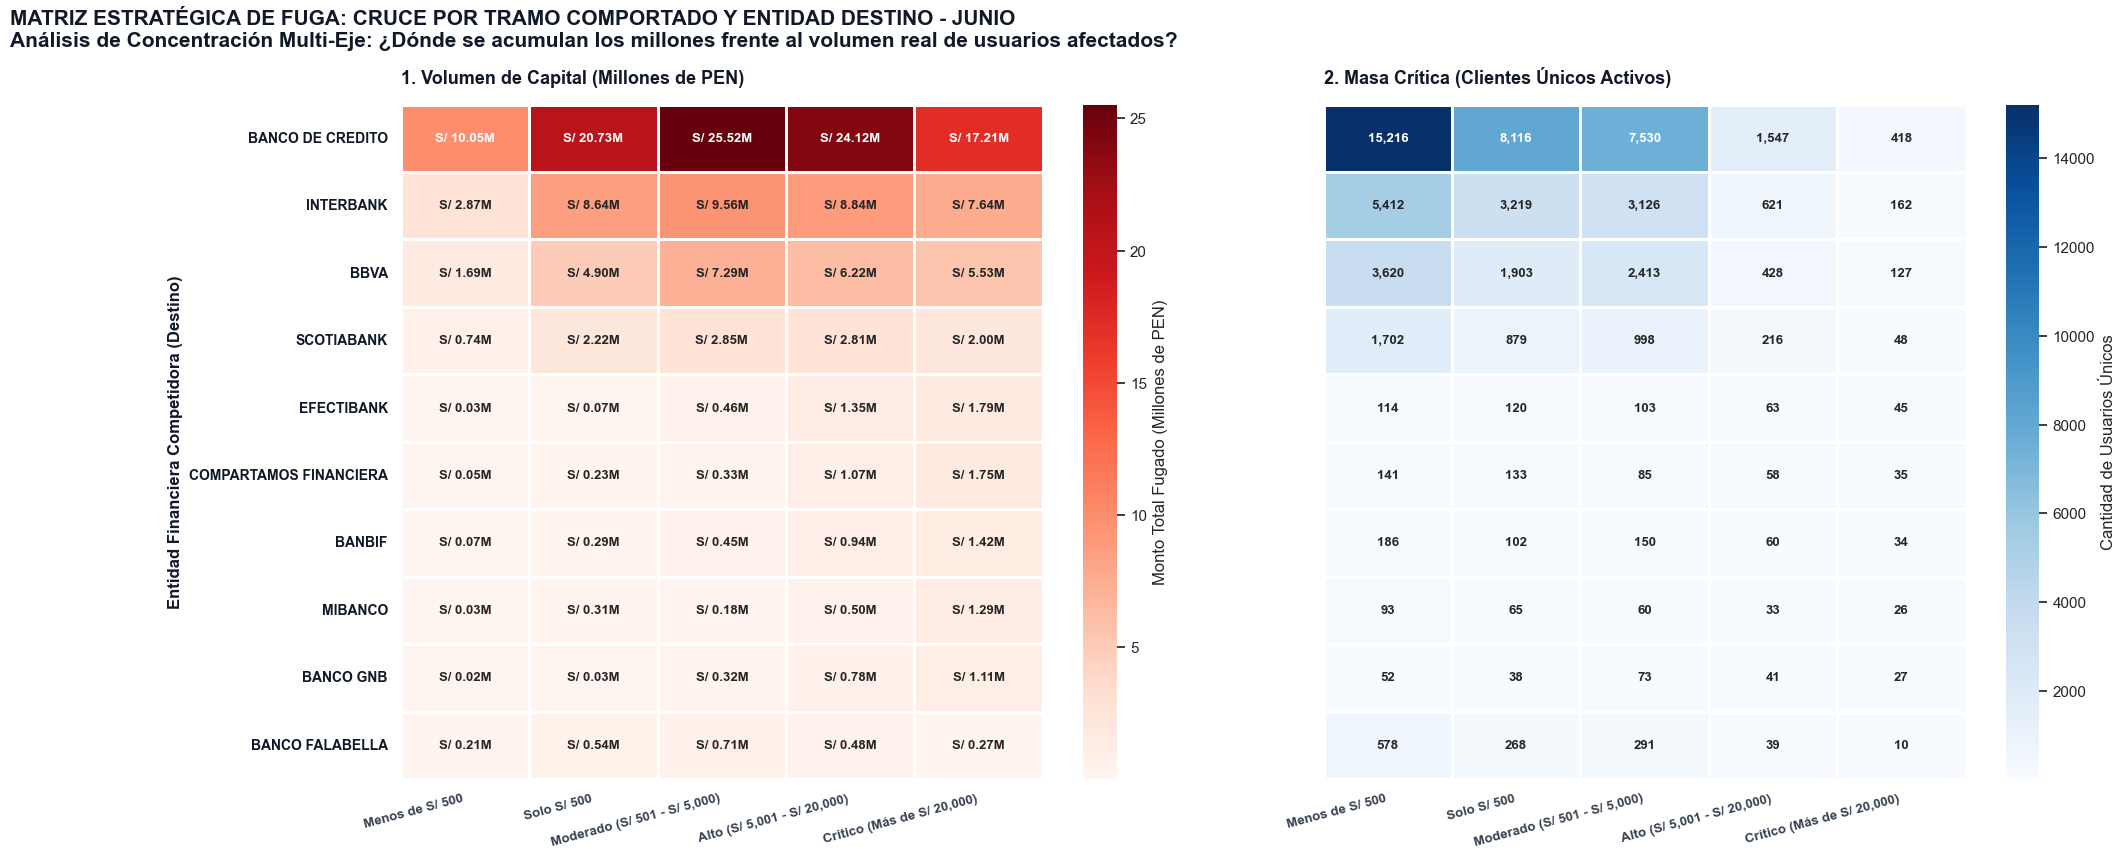

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustamos el estilo visual base premium plano
sns.set_theme(style="white")

# =====================================================================
# 1. CONSOLIDACIÓN DE LOS TRAMOS EXACTOS (INCLUYE SOLO S/ 500)
# =====================================================================
# Ajustamos los límites para aislar estadísticamente el valor exacto de 500
nuevos_limites = [-np.inf, 499.99, 500.00, 5000.00, 20000.00, np.inf]

# Definimos las nuevas etiquetas de negocio
nuevos_tramos = [
    'Menos de S/ 500',
    'Solo S/ 500',                     # <--- TRAMO QUIRÚRGICO EXCLUSIVO
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

# Reclasificamos la data en df_otros con la nueva instrucción precisa
df_otros['RANGO_MONTO_OFICIAL'] = pd.cut(
    df_otros['IMPORTE TRANSFERENCIA'], 
    bins=nuevos_limites, 
    labels=nuevos_tramos
)

# Aseguramos que Pandas respete el orden categórico ejecutivo en el Heatmap
df_otros['RANGO_MONTO_OFICIAL'] = pd.Categorical(
    df_otros['RANGO_MONTO_OFICIAL'], 
    categories=nuevos_tramos, 
    ordered=True
)

# =====================================================================
# 2. PREPARACIÓN DE LAS MATRICES (TOP 10 BANCOS)
# =====================================================================
top_10_bancos = (
    df_otros.groupby('NOMBRE ENTIDAD DESTINO')['IMPORTE TRANSFERENCIA']
    .sum()
    .nlargest(10)
    .index
)
df_filtrado_heatmap = df_otros[df_otros['NOMBRE ENTIDAD DESTINO'].isin(top_10_bancos)]

# --- Matriz 1: Monto Total en Millones (Suma) ---
matriz_montos = df_filtrado_heatmap.pivot_table(
    index='NOMBRE ENTIDAD DESTINO', columns='RANGO_MONTO_OFICIAL',
    values='IMPORTE TRANSFERENCIA', aggfunc='sum', fill_value=0
).reindex(index=top_10_bancos, columns=nuevos_tramos)

matriz_millones = matriz_montos / 1_000_000

# --- Matriz 2: Número de Clientes Únicos (Nunique) ---
matriz_clientes = df_filtrado_heatmap.pivot_table(
    index='NOMBRE ENTIDAD DESTINO', columns='RANGO_MONTO_OFICIAL',
    values='CODIGO CLIENTE', aggfunc='nunique', fill_value=0
).reindex(index=top_10_bancos, columns=nuevos_tramos)

# =====================================================================
# 3. CONSTRUCCIÓN DE LA DOBLE VISTA EJECUTIVA (Monto vs. Clientes)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(23, 9.5), sharey=True)

# --- PANEL IZQUIERDO: MONTO EN MILLONES ---
sns.heatmap(
    matriz_millones, annot=True, fmt=",.2f", cmap="Reds", 
    linewidths=0.8, ax=ax1, cbar_kws={'label': 'Monto Total Fugado (Millones de PEN)'}
)
ax1.set_title("1. Volumen de Capital (Millones de PEN)", fontsize=13, weight='bold', pad=15, color='#111827', loc='left')
ax1.set_xlabel("", fontsize=11)
ax1.set_ylabel("Entidad Financiera Competidora (Destino)", fontsize=12, weight='bold', color='#111827')

for text in ax1.texts:
    val = float(text.get_text().replace(',', ''))
    text.set_text(f"S/ {val:,.2f}M" if val > 0 else "-")
    text.set_fontsize(9.5)
    text.set_weight('bold')

# --- PANEL DERECHO: CONTEO DE CLIENTES ÚNICOS ---
sns.heatmap(
    matriz_clientes, annot=True, fmt=",.0f", cmap="Blues", 
    linewidths=0.8, ax=ax2, cbar_kws={'label': 'Cantidad de Usuarios Únicos'}
)
ax2.set_title("2. Masa Crítica (Clientes Únicos Activos)", fontsize=13, weight='bold', pad=15, color='#111827', loc='left')
ax2.set_xlabel("", fontsize=11)
ax2.set_ylabel("")

for text in ax2.texts:
    val = float(text.get_text().replace(',', ''))
    text.set_text(f"{int(val):,}" if val > 0 else "-")
    text.set_fontsize(9.5)
    text.set_weight('bold')

# =====================================================================
# 4. DISEÑO DE CABECERAS Y AJUSTE DE MÁRGENES (SOLUCIÓN A ETIQUETAS)
# =====================================================================
for ax in [ax1, ax2]:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9.5, weight='semibold', color='#374151')
    ax.tick_params(left=False, bottom=False)

# Forzamos los nombres de las entidades financieras a la izquierda en negrita completa
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontsize=10, weight='bold', color='#111827')

# Título de Directorio
fig.suptitle(
    "MATRIZ ESTRATÉGICA DE FUGA: CRUCE POR TRAMO COMPORTADO Y ENTIDAD DESTINO - JUNIO\n"
    "Análisis de Concentración Multi-Eje: ¿Dónde se acumulan los millones frente al volumen real de usuarios afectados?",
    fontsize=15, weight='bold', color='#111827', y=0.96, x=0.03, ha='left'
)

# Dejamos 20% de espacio libre a la izquierda para que entren nombres largos (ej. BANCO DE CREDITO, BANCO CONTINENTAL, etc.)
plt.subplots_adjust(left=0.20, right=0.95, top=0.86, bottom=0.15, wspace=0.15)

plt.show()


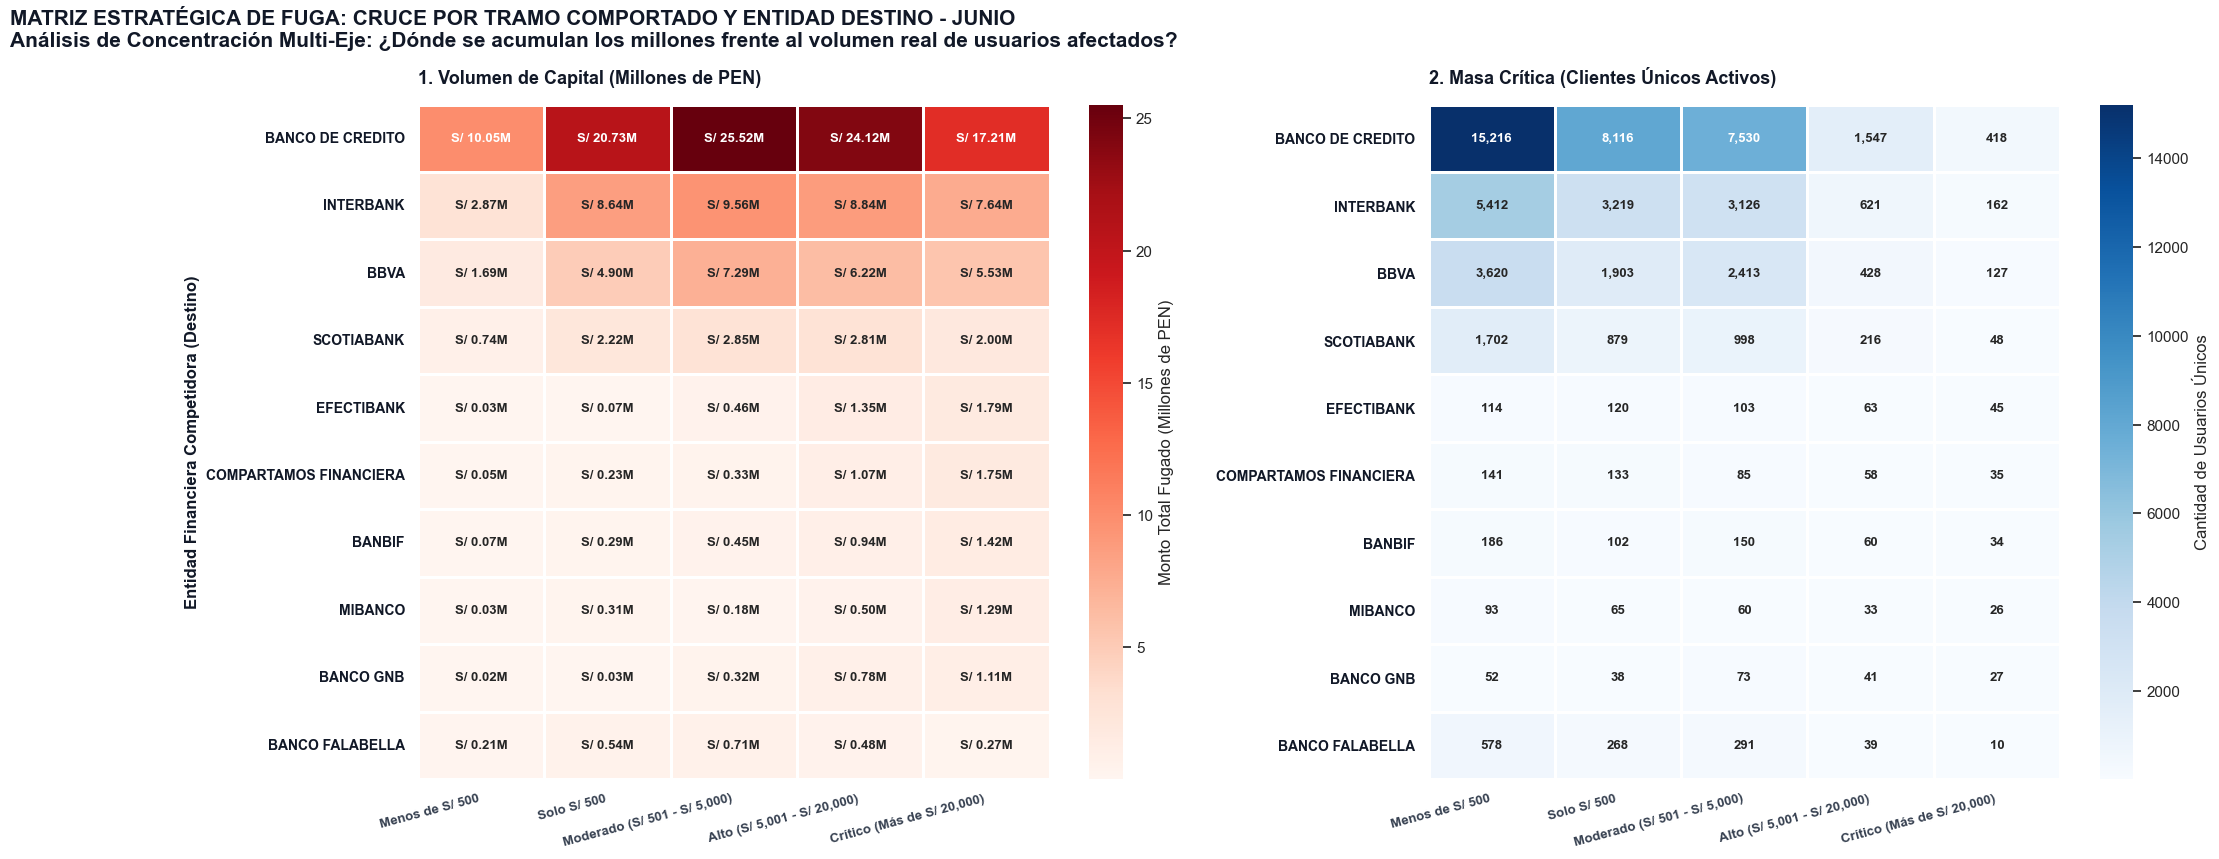

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustamos el estilo visual base premium plano
sns.set_theme(style="white")

# =====================================================================
# 1. CONSOLIDACIÓN DE LOS 5 TRAMOS REALES (INCLUYE SOLO S/ 500)
# =====================================================================
# Límites numéricos precisos para aislar el valor exacto de 500
nuevos_limites = [-np.inf, 499.99, 500.00, 5000.00, 20000.00, np.inf]

# Tus 5 tramos oficiales con el orden correcto
nuevos_tramos = [
    'Menos de S/ 500',
    'Solo S/ 500',                     # <--- TRAMO CLAVE AISLADO
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

# Volvemos a segmentar la data raíz
df_otros['RANGO_MONTO_OFICIAL'] = pd.cut(
    df_otros['IMPORTE TRANSFERENCIA'], 
    bins=nuevos_limites, 
    labels=nuevos_tramos
)

# Fijamos el orden categórico estricto para los subplots del Heatmap
df_otros['RANGO_MONTO_OFICIAL'] = pd.Categorical(
    df_otros['RANGO_MONTO_OFICIAL'], 
    categories=nuevos_tramos, 
    ordered=True
)

# =====================================================================
# 2. PREPARACIÓN DE LAS MATRICES (TOP 10 BANCOS)
# =====================================================================
top_10_bancos = (
    df_otros.groupby('NOMBRE ENTIDAD DESTINO')['IMPORTE TRANSFERENCIA']
    .sum()
    .nlargest(10)
    .index
)
df_filtrado_heatmap = df_otros[df_otros['NOMBRE ENTIDAD DESTINO'].isin(top_10_bancos)]

# --- Matriz 1: Monto Total en Millones (Suma) ---
matriz_montos = df_filtrado_heatmap.pivot_table(
    index='NOMBRE ENTIDAD DESTINO', columns='RANGO_MONTO_OFICIAL',
    values='IMPORTE TRANSFERENCIA', aggfunc='sum', fill_value=0
).reindex(index=top_10_bancos, columns=nuevos_tramos)

matriz_millones = matriz_montos / 1_000_000

# --- Matriz 2: Número de Clientes Únicos (Nunique) ---
matriz_clientes = df_filtrado_heatmap.pivot_table(
    index='NOMBRE ENTIDAD DESTINO', columns='RANGO_MONTO_OFICIAL',
    values='CODIGO CLIENTE', aggfunc='nunique', fill_value=0
).reindex(index=top_10_bancos, columns=nuevos_tramos)

# =====================================================================
# 3. CONSTRUCCIÓN DE LA DOBLE VISTA EJECUTIVA (Monto vs. Clientes)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 9.5), sharey=True)

# --- PANEL IZQUIERDO: MONTO EN MILLONES ---
sns.heatmap(
    matriz_millones, annot=True, fmt=",.2f", cmap="Reds", 
    linewidths=0.8, ax=ax1, cbar_kws={'label': 'Monto Total Fugado (Millones de PEN)'}
)
ax1.set_title("1. Volumen de Capital (Millones de PEN)", fontsize=13, weight='bold', pad=15, color='#111827', loc='left')
ax1.set_xlabel("", fontsize=11)
ax1.set_ylabel("Entidad Financiera Competidora (Destino)", fontsize=12, weight='bold', color='#111827')

for text in ax1.texts:
    val = float(text.get_text().replace(',', ''))
    text.set_text(f"S/ {val:,.2f}M" if val > 0 else "-")
    text.set_fontsize(9.5)
    text.set_weight('bold')

# --- PANEL DERECHO: CONTEO DE CLIENTES ÚNICOS ---
sns.heatmap(
    matriz_clientes, annot=True, fmt=",.0f", cmap="Blues", 
    linewidths=0.8, ax=ax2, cbar_kws={'label': 'Cantidad de Usuarios Únicos'}
)
ax2.set_title("2. Masa Crítica (Clientes Únicos Activos)", fontsize=13, weight='bold', pad=15, color='#111827', loc='left')
ax2.set_xlabel("", fontsize=11)
ax2.set_ylabel("")

for text in ax2.texts:
    val = float(text.get_text().replace(',', ''))
    text.set_text(f"{int(val):,}" if val > 0 else "-")
    text.set_fontsize(9.5)
    text.set_weight('bold')

# =====================================================================
# 4. SOLUCIÓN COMPLETA DE ETIQUETAS Y MARGENES DE ENTRADA
# =====================================================================
# Forzamos a que el panel derecho pinte los nombres de los bancos de forma explícita
ax2.yaxis.set_tick_params(labelleft=True)

# Aplicamos estilos homologados de texto a las etiquetas de ambos paneles
for ax in [ax1, ax2]:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9.5, weight='semibold', color='#374151')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10, weight='bold', color='#111827')
    ax.tick_params(left=False, bottom=False)

# Título Principal Directivo
fig.suptitle(
    "MATRIZ ESTRATÉGICA DE FUGA: CRUCE POR TRAMO COMPORTADO Y ENTIDAD DESTINO - JUNIO\n"
    "Análisis de Concentración Multi-Eje: ¿Dónde se acumulan los millones frente al volumen real de usuarios afectados?",
    fontsize=15, weight='bold', color='#111827', y=0.96, x=0.03, ha='left'
)

# Dejamos 20% de espacio a la izquierda para los textos del eje Y y abrimos espacio intermedio (wspace) para que no se choque nada
plt.subplots_adjust(left=0.20, right=0.95, top=0.86, bottom=0.15, wspace=0.28)

plt.show()


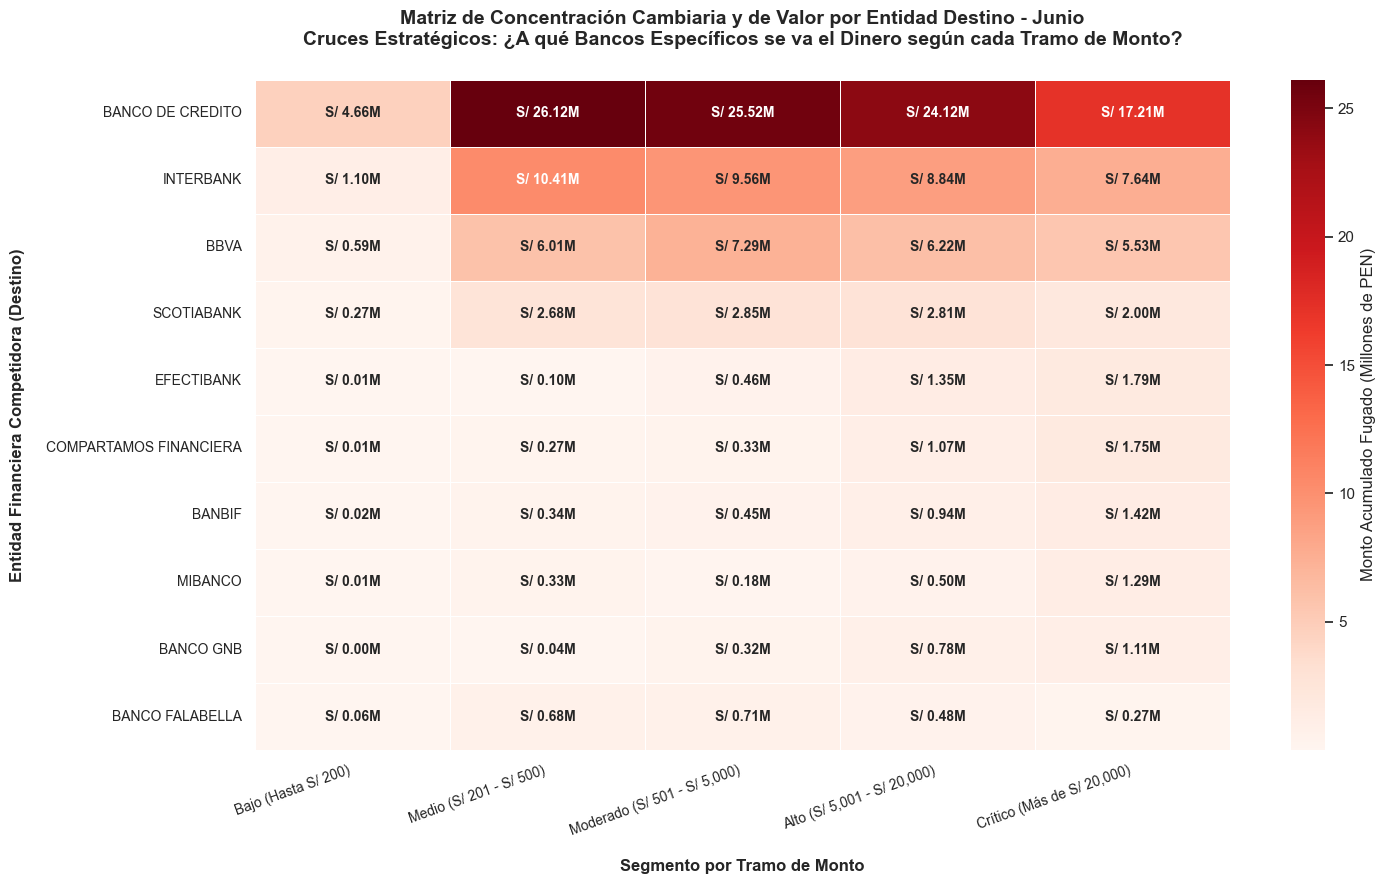

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. CONSOLIDACIÓN DE TUS 5 RANGOS OFICIALES
# =====================================================================
# Límites numéricos exactos para tus tramos definidos
limites = [-np.inf, 200, 500, 5000, 20000, np.inf]

# Tu orden lógico oficial (X)
orden_tramos = [
    'Bajo (Hasta S/ 200)',
    'Medio (S/ 201 - S/ 500)',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

# Aseguramos la columna exacta en df_otros con tus etiquetas oficiales
df_otros['RANGO_MONTO_OFICIAL'] = pd.cut(
    df_otros['IMPORTE TRANSFERENCIA'], 
    bins=limites, 
    labels=orden_tramos
)

# =====================================================================
# 2. SELECCIÓN DEL TOP 10 DE ENTIDADES DESTINO (ORDEN DE MAYOR A MENOR)
# =====================================================================
top_entidades = (
    df_otros.groupby('NOMBRE ENTIDAD DESTINO')['IMPORTE TRANSFERENCIA']
    .sum()
    .nlargest(10)
    .index
)

# Filtrar el DataFrame para quedarnos únicamente con los 10 bancos principales
df_filtrado_mapa = df_otros[df_otros['NOMBRE ENTIDAD DESTINO'].isin(top_entidades)]

# =====================================================================
# 3. CREACIÓN DE LA MATRIZ DE MILLONES (TABLA PIVOTE)
# =====================================================================
matriz_montos = df_filtrado_mapa.pivot_table(
    index='NOMBRE ENTIDAD DESTINO',
    columns='RANGO_MONTO_OFICIAL',
    values='IMPORTE TRANSFERENCIA',
    aggfunc='sum',
    fill_value=0
)

# Reorganizar filas de mayor a menor total y columnas usando tu orden estricto
matriz_montos = matriz_montos.reindex(index=top_entidades, columns=orden_tramos)

# Transformar los valores numéricos absolutos a formato de Millones (M)
matriz_millones = matriz_montos / 1_000_000

# =====================================================================
# 4. DISEÑO Y CONSTRUCCIÓN DEL MAPA DE CALOR (HEATMAP)
# =====================================================================
plt.figure(figsize=(15, 9))
sns.set_theme(style="white")

# Usamos la paleta "Reds" para mantener los tonos rojos corporativos
ax = sns.heatmap(
    matriz_millones,
    annot=True,             # Activa los textos numéricos dentro de los bloques
    fmt=",.2f",             # Muestra dos decimales fijos para los millones
    cmap="Reds",            # Paleta de degradado de rojos de la imagen
    linewidths=0.6,         # Línea delgada blanca para separar las celdas
    cbar_kws={'label': 'Monto Acumulado Fugado (Millones de PEN)'}
)

# Modificar el texto interno de cada cuadrante para inyectar el formato monetario exacto
for text in ax.texts:
    valor_celda = float(text.get_text().replace(',', ''))
    text.set_text(f"S/ {valor_celda:,.2f}M")
    text.set_fontsize(10)
    text.set_weight('semibold')

# =====================================================================
# 5. PERSONALIZACIÓN DE TÍTULOS Y EJES CORPORATIVOS
# =====================================================================
plt.title(
    'Matriz de Concentración Cambiaria y de Valor por Entidad Destino - Junio\n'
    'Cruces Estratégicos: ¿A qué Bancos Específicos se va el Dinero según cada Tramo de Monto?',
    fontsize=14, weight='bold', pad=25
)

plt.xlabel('Segmento por Tramo de Monto', fontsize=12, labelpad=15, weight='bold')
plt.ylabel('Entidad Financiera Competidora (Destino)', fontsize=12, labelpad=15, weight='bold')

# Ajustar rotación de los textos largos en los ejes para evitar colisiones visuales
plt.xticks(rotation=20, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()


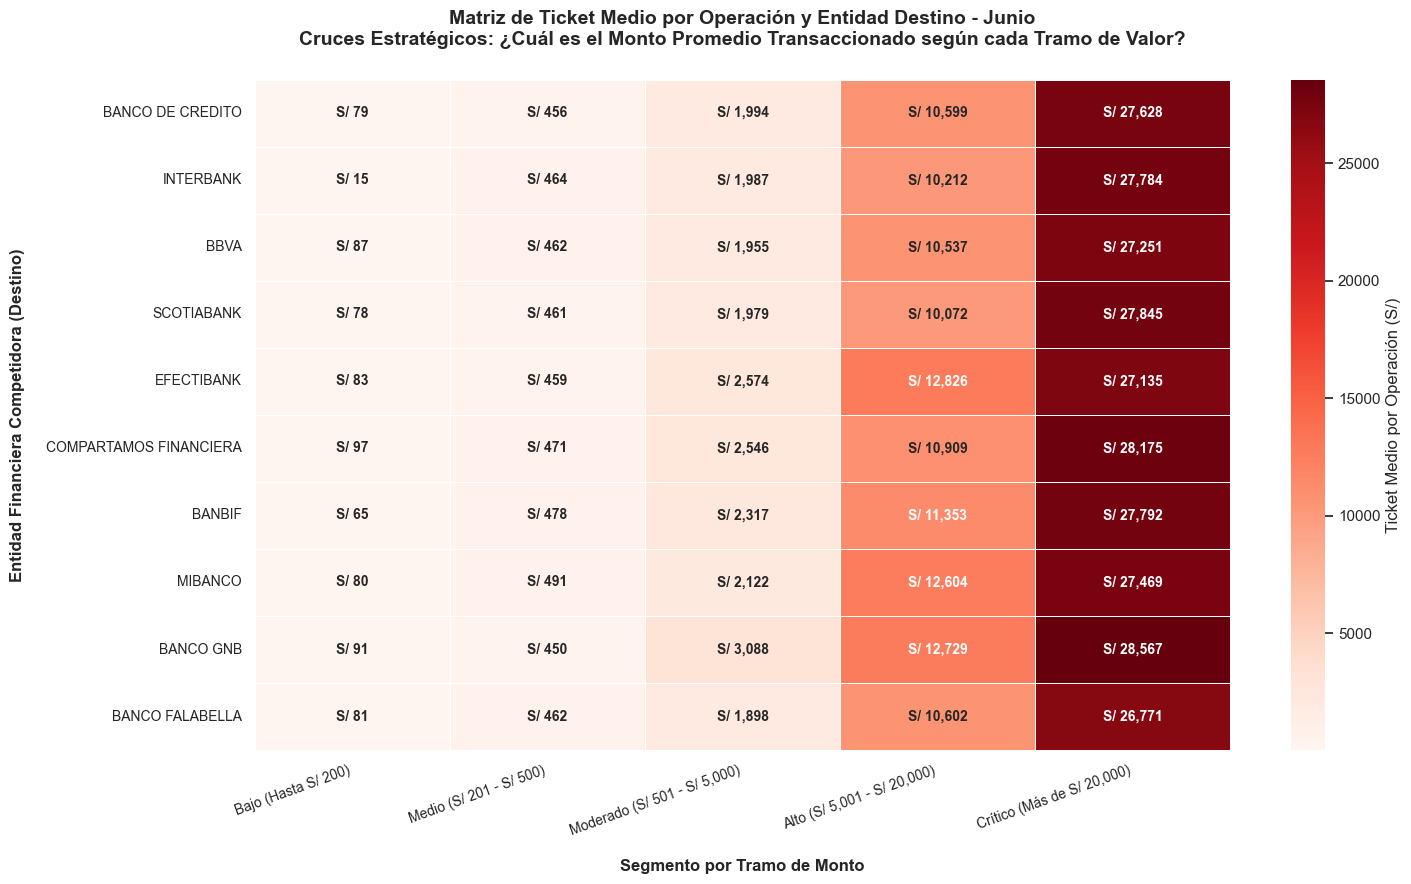

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. CONSOLIDACIÓN DE TUS 5 RANGOS OFICIALES
# =====================================================================
limites = [-np.inf, 200, 500, 5000, 20000, np.inf]

orden_tramos = [
    'Bajo (Hasta S/ 200)',
    'Medio (S/ 201 - S/ 500)',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

df_otros['RANGO_MONTO_OFICIAL'] = pd.cut(
    df_otros['IMPORTE TRANSFERENCIA'], 
    bins=limites, 
    labels=orden_tramos
)

# =====================================================================
# 2. SELECCIÓN DEL TOP 10 DE ENTIDADES DESTINO (POR MONTO TOTAL ACUMULADO)
# =====================================================================
# Mantenemos las mismas 10 entidades principales para comparar la misma muestra
top_entidades = (
    df_otros.groupby('NOMBRE ENTIDAD DESTINO')['IMPORTE TRANSFERENCIA']
    .sum()
    .nlargest(10)
    .index
)

df_filtrado_mapa = df_otros[df_otros['NOMBRE ENTIDAD DESTINO'].isin(top_entidades)]

# =====================================================================
# 3. CREACIÓN DE LA MATRIZ DE TICKET MEDIO (CAMBIO CLAVE: aggfunc='mean')
# =====================================================================
matriz_tickets = df_filtrado_mapa.pivot_table(
    index='NOMBRE ENTIDAD DESTINO',
    columns='RANGO_MONTO_OFICIAL',
    values='IMPORTE TRANSFERENCIA',
    aggfunc='mean',          # <--- CAMBIO CLAVE: Calcula el promedio en lugar de la suma
    fill_value=0
)

# Reorganizar filas y columnas
matriz_tickets = matriz_tickets.reindex(index=top_entidades, columns=orden_tramos)

# =====================================================================
# 4. DISEÑO Y CONSTRUCCIÓN DEL MAPA DE CALOR (HEATMAP)
# =====================================================================
plt.figure(figsize=(15, 9))
sns.set_theme(style="white")

# Usamos la paleta "Reds" solicitada
ax = sns.heatmap(
    matriz_tickets,
    annot=True,             
    fmt=",.0f",             # Formato entero sin decimales para que el mapa respire mejor
    cmap="Reds",            
    linewidths=0.6,         
    cbar_kws={'label': 'Ticket Medio por Operación (S/)'}
)

# Modificar el texto interno para inyectar el formato de Ticket Promedio exacto
for text in ax.texts:
    valor_celda = float(text.get_text().replace(',', ''))
    if valor_celda > 0:
        text.set_text(f"S/ {valor_celda:,.0f}") # Muestra "S/ 15,420" de forma limpia
    else:
        text.set_text("-") # Deja un guión limpio si no hubo operaciones en ese cruce
    text.set_fontsize(10)
    text.set_weight('semibold')

# =====================================================================
# 5. PERSONALIZACIÓN DE TÍTULOS Y EJES CORPORATIVOS
# =====================================================================
plt.title(
    'Matriz de Ticket Medio por Operación y Entidad Destino - Junio\n'
    'Cruces Estratégicos: ¿Cuál es el Monto Promedio Transaccionado según cada Tramo de Valor?',
    fontsize=14, weight='bold', pad=25
)

plt.xlabel('Segmento por Tramo de Monto', fontsize=12, labelpad=15, weight='bold')
plt.ylabel('Entidad Financiera Competidora (Destino)', fontsize=12, labelpad=15, weight='bold')

# Ajustar rotación para visualización ejecutiva impecable
plt.xticks(rotation=20, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

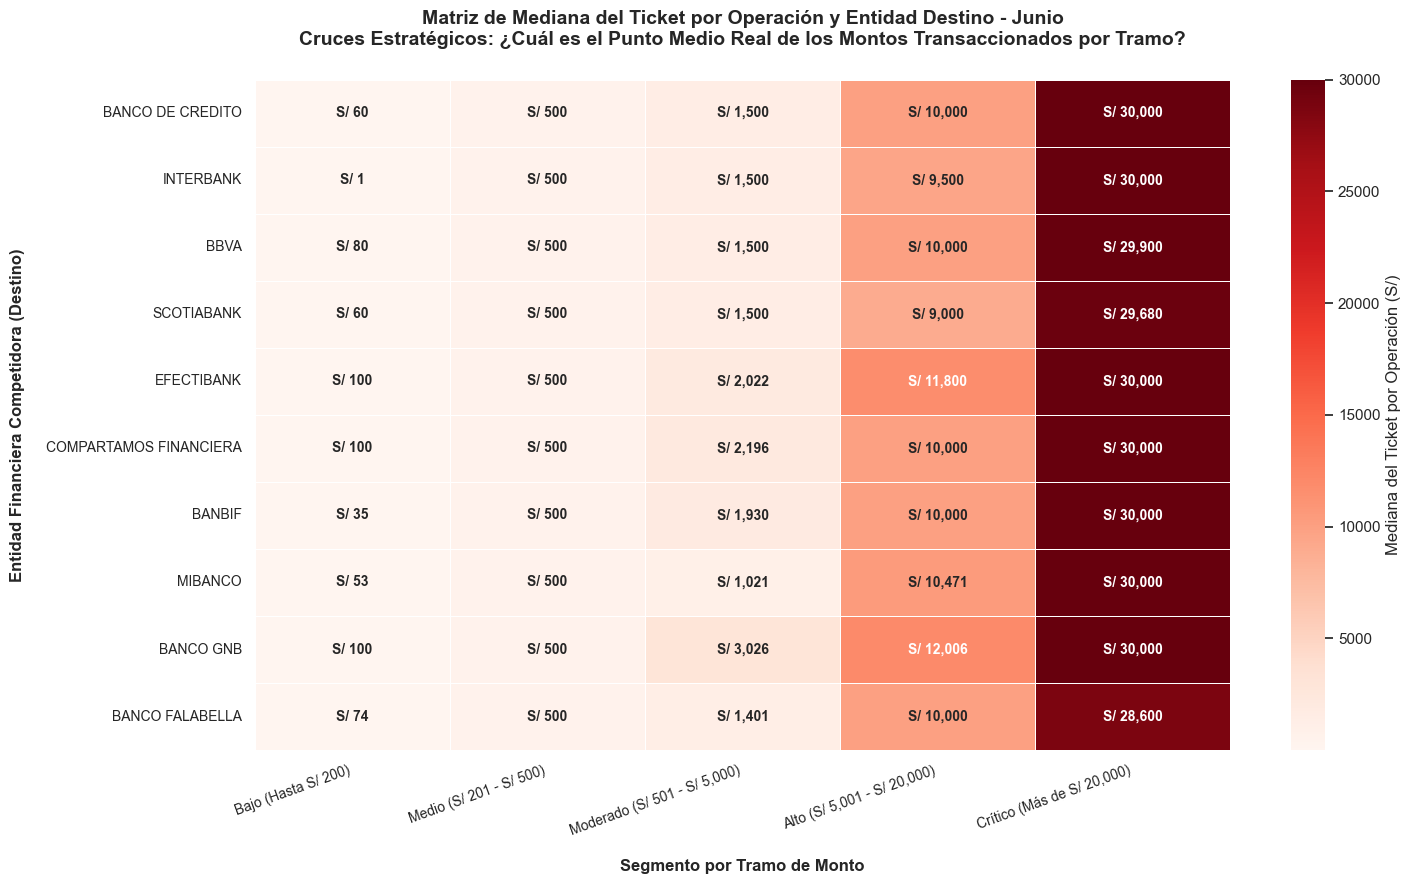

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. CONSOLIDACIÓN DE TUS 5 RANGOS OFICIALES
# =====================================================================
limites = [-np.inf, 200, 500, 5000, 20000, np.inf]

orden_tramos = [
    'Bajo (Hasta S/ 200)',
    'Medio (S/ 201 - S/ 500)',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

df_otros['RANGO_MONTO_OFICIAL'] = pd.cut(
    df_otros['IMPORTE TRANSFERENCIA'], 
    bins=limites, 
    labels=orden_tramos
)

# =====================================================================
# 2. SELECCIÓN DEL TOP 10 DE ENTIDADES DESTINO (POR MONTO TOTAL ACUMULADO)
# =====================================================================
top_entidades = (
    df_otros.groupby('NOMBRE ENTIDAD DESTINO')['IMPORTE TRANSFERENCIA']
    .sum()
    .nlargest(10)
    .index
)

df_filtrado_mapa = df_otros[df_otros['NOMBRE ENTIDAD DESTINO'].isin(top_entidades)]

# =====================================================================
# 3. CREACIÓN DE LA MATRIZ DE MEDIANA DEL TICKET (CAMBIO CLAVE: aggfunc='median')
# =====================================================================
matriz_mediana = df_filtrado_mapa.pivot_table(
    index='NOMBRE ENTIDAD DESTINO',
    columns='RANGO_MONTO_OFICIAL',
    values='IMPORTE TRANSFERENCIA',
    aggfunc='median',         # <--- CAMBIO CLAVE: Calcula la mediana en lugar del promedio
    fill_value=0
)

# Reorganizar filas y columnas
matriz_mediana = matriz_mediana.reindex(index=top_entidades, columns=orden_tramos)

# =====================================================================
# 4. DISEÑO Y CONSTRUCCIÓN DEL MAPA DE CALOR (HEATMAP)
# =====================================================================
plt.figure(figsize=(15, 9))
sns.set_theme(style="white")

ax = sns.heatmap(
    matriz_mediana,
    annot=True,             
    fmt=",.0f",             # Formato entero sin decimales para máxima legibilidad
    cmap="Reds",            
    linewidths=0.6,         
    cbar_kws={'label': 'Mediana del Ticket por Operación (S/)'} # <--- ACTUALIZADO
)

# Modificar el texto interno para inyectar el formato monetario exacto
for text in ax.texts:
    valor_celda = float(text.get_text().replace(',', ''))
    if valor_celda > 0:
        text.set_text(f"S/ {valor_celda:,.0f}") 
    else:
        text.set_text("-") 
    text.set_fontsize(10)
    text.set_weight('semibold')

# =====================================================================
# 5. PERSONALIZACIÓN DE TÍTULOS Y EJES CORPORATIVOS
# =====================================================================
plt.title(
    'Matriz de Mediana del Ticket por Operación y Entidad Destino - Junio\n'
    'Cruces Estratégicos: ¿Cuál es el Punto Medio Real de los Montos Transaccionados por Tramo?',
    fontsize=14, weight='bold', pad=25
)

plt.xlabel('Segmento por Tramo de Monto', fontsize=12, labelpad=15, weight='bold')
plt.ylabel('Entidad Financiera Competidora (Destino)', fontsize=12, labelpad=15, weight='bold')

# Ajustar rotación para visualización ejecutiva impecable
plt.xticks(rotation=20, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()


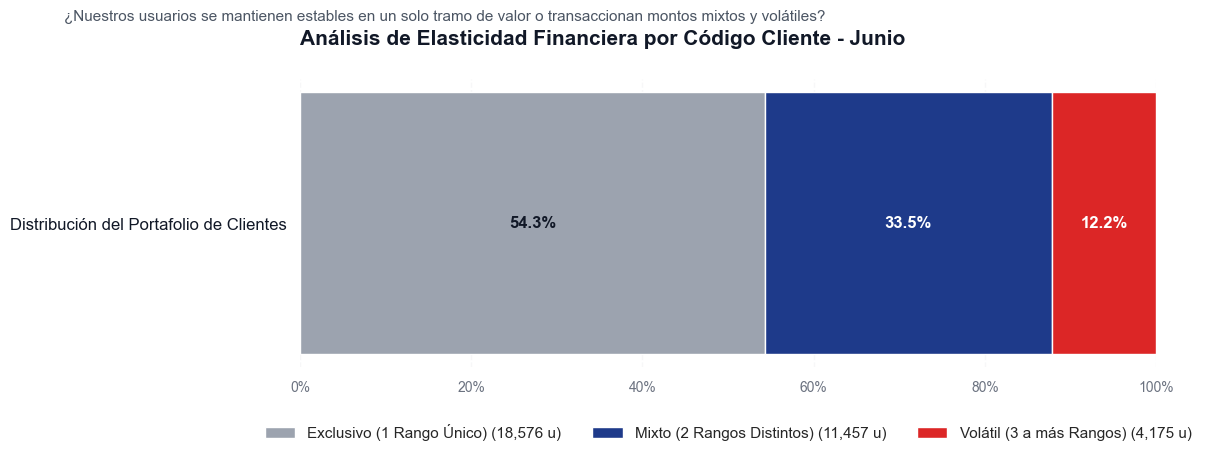

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustamos el estilo visual institucional limpio
sns.set_theme(style="white")

# =====================================================================
# 1. PROCESAMIENTO DE DATOS: CONTAR RANGOS ÚNICOS POR CLIENTE
# =====================================================================
# Agrupamos por cliente y contamos cuántos 'RANGO_MONTO_OFICIAL' diferentes usó en el mes
rangos_por_cliente = df_otros.groupby('CODIGO CLIENTE')['RANGO_MONTO_OFICIAL'].nunique().reset_index()
rangos_por_cliente.columns = ['CODIGO CLIENTE', 'CANTIDAD_RANGOS']

# Clasificamos a los clientes según su nivel de diversificación de montos
def clasificar_comportamiento(cant):
    if cant == 1:
        return "Exclusivo (1 Rango Único)"
    elif cant == 2:
        return "Mixto (2 Rangos Distintos)"
    else:
        return "Volátil (3 a más Rangos)"

rangos_por_cliente['Perfil de Comportamiento'] = rangos_por_cliente['CANTIDAD_RANGOS'].apply(clasificar_comportamiento)

# =====================================================================
# 2. CÁLCULO DE VOLÚMENES Y PORCENTAJES PARA EL GRÁFICO
# =====================================================================
# Contamos cuántos clientes caen en cada perfil
df_resumen = rangos_por_cliente['Perfil de Comportamiento'].value_counts().reset_index()
df_resumen.columns = ['Perfil', 'Cantidad_Clientes']

# Aseguramos un orden lógico ejecutivo en la visualización
orden_perfiles = ["Exclusivo (1 Rango Único)", "Mixto (2 Rangos Distintos)", "Volátil (3 a más Rangos)"]
df_resumen['Perfil'] = pd.Categorical(df_resumen['Perfil'], categories=orden_perfiles, ordered=True)
df_resumen = df_resumen.sort_values('Perfil').reset_index(drop=True)

# Calculamos los porcentajes de participación para las etiquetas
total_clientes = df_resumen['Cantidad_Clientes'].sum()
df_resumen['Porcentaje'] = (df_resumen['Cantidad_Clientes'] / total_clientes) * 100

# =====================================================================
# 3. DISEÑO Y CONSTRUCCIÓN DEL GRÁFICO EJECUTIVO
# =====================================================================
plt.figure(figsize=(12, 5))

# Paleta premium de la línea corporativa (Gris base, Azul institucional y un Rojo/Coral de alerta)
colores_perfiles = ["#9CA3AF", "#1E3A8A", "#DC2626"] 

# Dibujamos las barras horizontales de manera acumulada para formar el 100%
acumulado = 0
bars = []

for i, row in df_resumen.iterrows():
    b = plt.barh(
        y=['Distribución del Portafolio de Clientes'], 
        width=[row['Porcentaje']], 
        left=[acumulado], 
        color=colores_perfiles[i], 
        label=f"{row['Perfil']} ({row['Cantidad_Clientes']:,} u)",
        height=0.45
    )
    bars.append(b)
    
    # Inyectamos el texto del porcentaje exacto dentro de cada bloque de la barra
    if row['Porcentaje'] > 5: # Solo muestra la etiqueta si el bloque es lo suficientemente ancho
        plt.text(
            x=acumulado + (row['Porcentaje'] / 2),
            y=0,
            s=f"{row['Porcentaje']:.1f}%",
            va='center',
            ha='center',
            color='white' if i > 0 else '#111827',
            weight='bold',
            fontsize=12
        )
    acumulado += row['Porcentaje']

# =====================================================================
# 4. PULIDO ESTÉTICO Y LEYENDA DIRECTIVA
# =====================================================================
# Ajustes de ejes
plt.xlim(0, 100)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{int(x)}%"))
plt.tick_params(axis='y', labelsize=12, labelcolor='#111827', left=False)
plt.tick_params(axis='x', colors='#6B7280', labelsize=10)

# Remoción de bordes innecesarios para diseño limpio
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.3, color='#E5E7EB')

# Posicionamiento estratégico de la leyenda en la parte inferior
plt.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), 
    ncol=3, 
    frameon=False, 
    fontsize=11
)

# Títulos con la jerarquía visual que pide tu directorio
plt.title(
    "Análisis de Elasticidad Financiera por Código Cliente - Junio", 
    fontsize=15, weight='bold', color='#111827', pad=25, loc='left'
)
plt.suptitle(
    "¿Nuestros usuarios se mantienen estables en un solo tramo de valor o transaccionan montos mixtos y volátiles?",
    fontsize=11, color='#4B5563', y=0.94, x=0.06, ha='left'
)

plt.tight_layout()
plt.show()


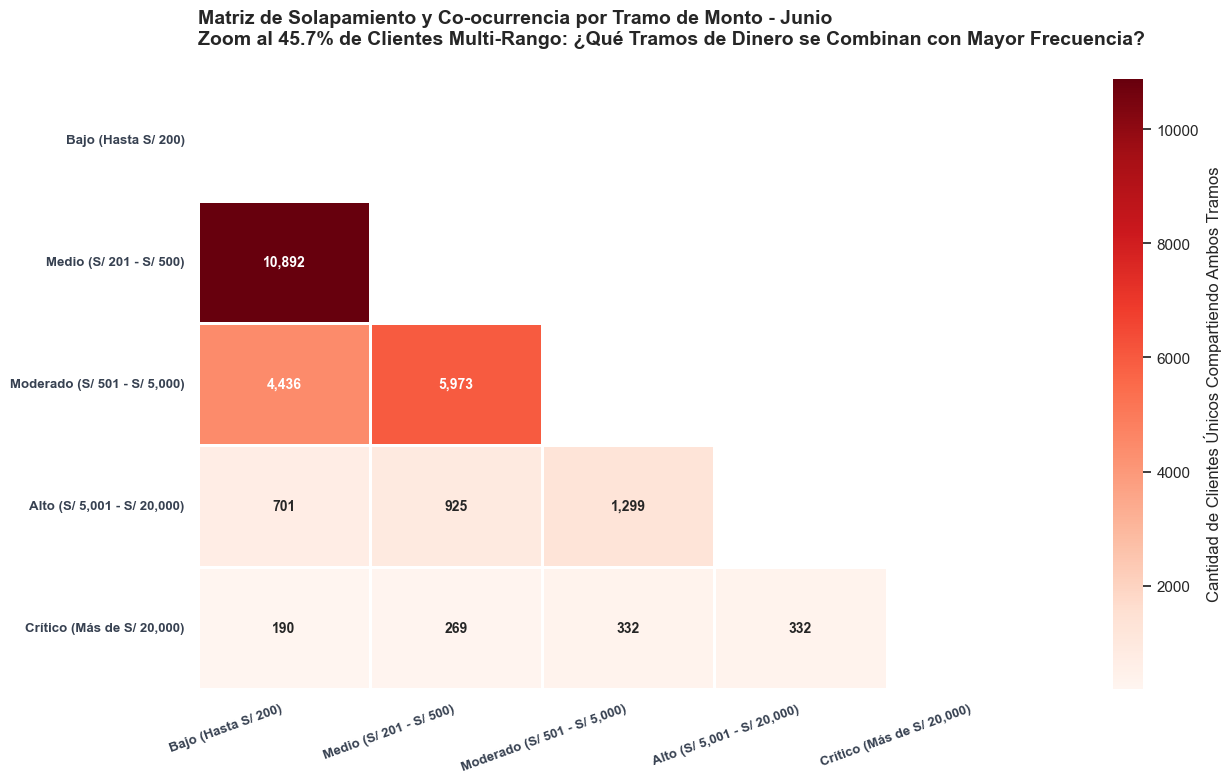

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Ajustamos el estilo visual base limpio
sns.set_theme(style="white")

# =====================================================================
# 1. FILTRAR SOLO CLIENTES CON MÁS DE UN RANGO ÚNICO
# =====================================================================
# Agrupamos los rangos reales por cada cliente en listas de valores únicos
df_rangos_cliente = df_otros.groupby('CODIGO CLIENTE')['RANGO_MONTO_OFICIAL'].apply(lambda x: list(set(x))).reset_index()

# Filtramos para quedarnos estrictamente con los clientes de comportamiento Mixto o Volátil
df_multi_rango = df_rangos_cliente[df_rangos_cliente['RANGO_MONTO_OFICIAL'].apply(len) > 1].reset_index(drop=True)

# =====================================================================
# 2. CONSTRUIR LA MATRIZ DE CO-OCURRENCIA (CRUCES DE COMPORTAMIENTO)
# =====================================================================
# Definimos el orden estricto de las etiquetas que ya manejas
orden_tramos = [
    'Bajo (Hasta S/ 200)',
    'Medio (S/ 201 - S/ 500)',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

# Inicializamos una matriz vacía indexada por tus tramos oficiales
matriz_cruces = pd.DataFrame(0, index=orden_tramos, columns=orden_tramos)

# Llenamos la matriz contando los pares de combinaciones por cada usuario
for lista_rangos in df_multi_rango['RANGO_MONTO_OFICIAL']:
    # Generamos todas las combinaciones posibles de 2 en 2 para ese cliente
    pares = combinations(lista_rangos, 2)
    for p1, p2 in pares:
        if p1 in orden_tramos and p2 in orden_tramos:
            # Sumamos el cliente en ambos sentidos para que la matriz sea simétrica
            matriz_cruces.loc[p1, p2] += 1
            matriz_cruces.loc[p2, p1] += 1

# Creamos una máscara para ocultar la mitad superior (diagonal), evitando duplicidad visual
mascara = np.triu(np.ones_like(matriz_cruces, dtype=bool))

# =====================================================================
# 3. DISEÑO Y CONSTRUCCIÓN DEL GRÁFICO CORPORATIVO (HEATMAP DE COMBINACIONES)
# =====================================================================
plt.figure(figsize=(13, 8))

# Graficamos el mapa usando tonos rojos para mantener la línea de riesgo y alertas
ax = sns.heatmap(
    matriz_cruces,
    mask=mascara,           # Oculta la mitad redundante para un diseño más limpio
    annot=True,             # Muestra la cantidad de clientes en los bloques
    fmt=",d",               # Formato de números enteros con separador de miles
    cmap="Reds",            
    linewidths=0.8,         
    cbar_kws={'label': 'Cantidad de Clientes Únicos Compartiendo Ambos Tramos'}
)

# Estilizado fino de las etiquetas internas de volumen
for text in ax.texts:
    text.set_fontsize(10)
    text.set_weight('bold')

# =====================================================================
# 4. PERSONALIZACIÓN DE TÍTULOS Y EJES EJECUTIVOS
# =====================================================================
plt.title(
    'Matriz de Solapamiento y Co-ocurrencia por Tramo de Monto - Junio\n'
    'Zoom al 45.7% de Clientes Multi-Rango: ¿Qué Tramos de Dinero se Combinan con Mayor Frecuencia?',
    fontsize=14, weight='bold', pad=25, loc='left'
)

# Ajuste de rotaciones limpias para evitar colisiones tipográficas
plt.xticks(rotation=20, ha='right', fontsize=9.5, weight='semibold', color='#374151')
plt.yticks(rotation=0, fontsize=9.5, weight='semibold', color='#374151')

plt.tight_layout()
plt.show()


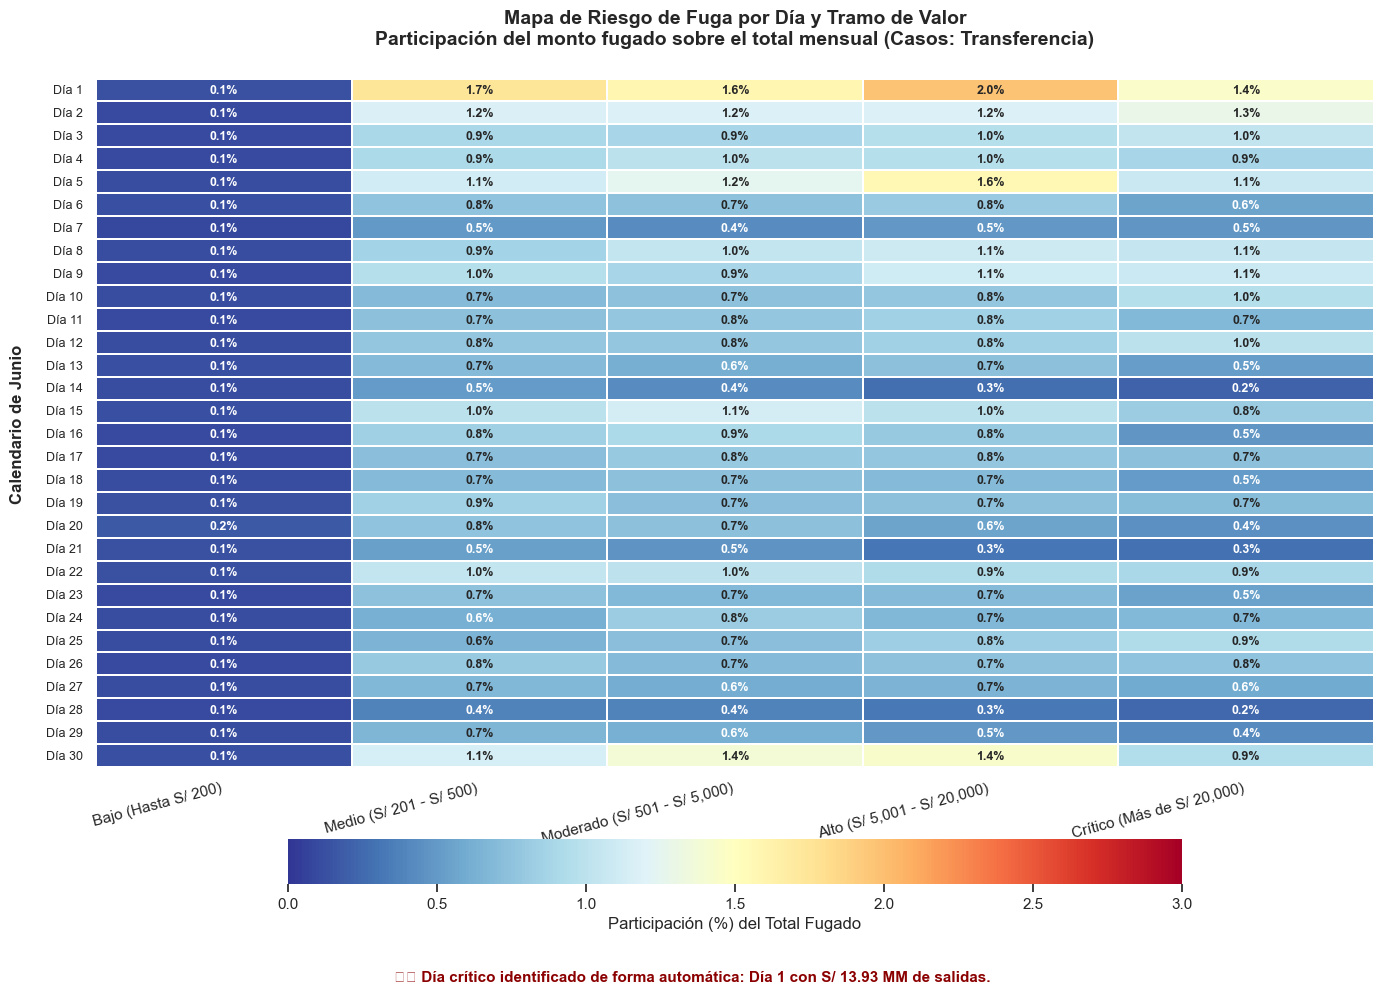

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =====================================================================
# 🛠️ PASO CORRECTIVO EXTRA: ASEGURAR COLUMNAS EN DF_OTROS
# =====================================================================
# 1. Forzar formato correcto de fecha y crear la columna 'Día'
df_otros['FECHA TRANSFERENCIA'] = pd.to_datetime(df_otros['FECHA TRANSFERENCIA'], format='%Y%m%d')
df_otros['Día'] = df_otros['FECHA TRANSFERENCIA'].dt.day

# 2. Forzar la recreación exacta de 'RANGO_MONTO' por si se borró al filtrar
limites = [-np.inf, 200, 500, 5000, 20000, np.inf]
etiquetas = [
    'Bajo (Hasta S/ 200)',
    'Medio (S/ 201 - S/ 500)',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]
df_otros['RANGO_MONTO'] = pd.cut(df_otros['IMPORTE TRANSFERENCIA'], bins=limites, labels=etiquetas)


# =====================================================================
# 1. PREPARACIÓN DE LA MATRIZ (CALENDARIO) - YA NO DARÁ ERROR
# =====================================================================
orden_tramos = [
    'Bajo (Hasta S/ 200)',
    'Medio (S/ 201 - S/ 500)',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

matriz_calendario = df_otros.pivot_table(
    index='Día',
    columns='RANGO_MONTO',
    values='IMPORTE TRANSFERENCIA',
    aggfunc='sum',
    fill_value=0
)

# Reindexar el eje X para mantener el orden lógico de los tramos
matriz_calendario = matriz_calendario.reindex(columns=orden_tramos, fill_value=0)

# Asegurar que aparezcan los 30 días en el eje Y
matriz_calendario = matriz_calendario.reindex(range(1, 31), fill_value=0)

monto_total_global = df_otros['IMPORTE TRANSFERENCIA'].sum()
matriz_porcentajes = (matriz_calendario / monto_total_global) * 100

# =====================================================================
# 2. IDENTIFICACIÓN AUTOMÁTICA DEL DÍA CRÍTICO
# =====================================================================
fuga_diaria = df_otros.groupby('Día')['IMPORTE TRANSFERENCIA'].sum()
dia_critico = fuga_diaria.idxmax()
monto_dia_critico_m = fuga_diaria.max() / 1_000_000

# =====================================================================
# 3. CONSTRUCCIÓN DEL MAPA DE CALOR (HEATMAP)
# =====================================================================
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    matriz_porcentajes,
    annot=True,              
    fmt=".1f",               
    cmap="RdYlBu_r",         
    vmin=0.0, vmax=3.0,      
    linewidths=0.2,          
    cbar_kws={
        'label': 'Participación (%) del Total Fugado', 
        'orientation': 'horizontal', 
        'pad': 0.08, 
        'shrink': 0.7
    }
)

for text in ax.texts:
    val = float(text.get_text())
    if val > 0:
        text.set_text(f"{val:.1f}%")
        text.set_fontsize(9)
        text.set_weight('semibold')
    else:
        text.set_text("") 

# =====================================================================
# 4. PERSONALIZACIÓN ESTÉTICA DEL CALENDARIO
# =====================================================================
etiquetas_y = [f"Día {i}" for i in range(1, 31)]
ax.set_yticklabels(etiquetas_y, rotation=0, fontsize=9)

plt.title(
    'Mapa de Riesgo de Fuga por Día y Tramo de Valor\n'
    'Participación del monto fugado sobre el total mensual (Casos: Transferencia)',
    fontsize=14, weight='bold', pad=25
)
ax.set_ylabel('Calendario de Junio', fontsize=12, labelpad=15, weight='bold')
ax.set_xlabel('Segmento de Rango de Monto', fontsize=12, labelpad=15, weight='bold')

plt.xticks(rotation=15, ha='right')

plt.figtext(
    0.5, 0.01, 
    f"⚠️ Día crítico identificado de forma automática: Día {dia_critico} con S/ {monto_dia_critico_m:,.2f} MM de salidas.", 
    ha="center", fontsize=11, color="darkred", weight="bold"
)

plt.tight_layout()
plt.show()


El mapa de calor confirma nuestra hipótesis de concentración: el tramo Bajo de transacciones hormiga no afecta la aguja del banco. El peligro real está en el tramo Crítico y Alto, que mantiene un drenaje constante de entre 0.7% y 1.4% de participación diario durante todo el mes. Sin embargo, nuestro punto más vulnerable ocurre en el Día 1, donde sufrimos un impacto masivo de S/ 13.93 Millones concentrado en los tramos más altos. Esto nos obliga a enfocar las reglas de monitoreo y los límites transaccionales especialmente en los arranques de mes y los cierres de quincena.

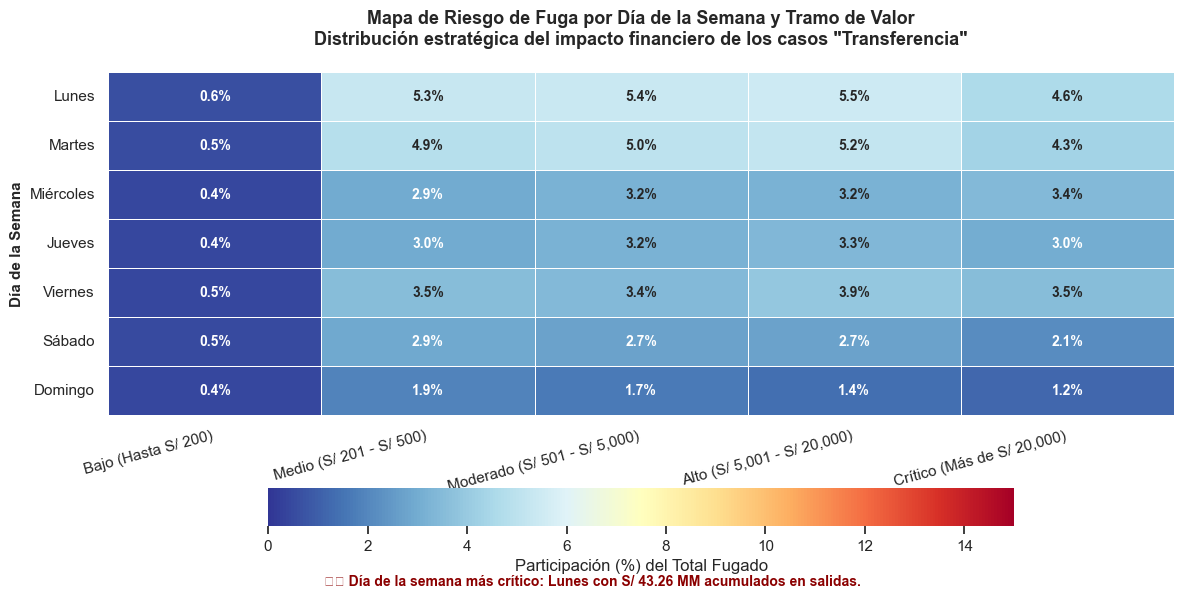

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. EXTRACCIÓN DEL DÍA DE LA SEMANA Y PREPARACIÓN DE LA MATRIZ
# =====================================================================
# Forzamos lectura correcta de fecha
df_otros['FECHA TRANSFERENCIA'] = pd.to_datetime(df_otros['FECHA TRANSFERENCIA'], dayfirst=True)

# Extraemos el nombre del día de la semana en español
df_otros['Dia_Semana'] = df_otros['FECHA TRANSFERENCIA'].dt.day_name(locale='es_ES')

# Orden lógico de las columnas (X)
orden_tramos = [
    'Bajo (Hasta S/ 200)',
    'Medio (S/ 201 - S/ 500)',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

# Orden lógico de las filas (Y) de Lunes a Domingo
orden_dias_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

# Crear la tabla pivote sumando los montos por Día de la Semana y Rango de Monto
matriz_calendario = df_otros.pivot_table(
    index='Dia_Semana',
    columns='RANGO_MONTO',
    values='IMPORTE TRANSFERENCIA',
    aggfunc='sum',
    fill_value=0
)

# Reindexar ejes X e Y para mantener la coherencia del negocio
matriz_calendario = matriz_calendario.reindex(columns=orden_tramos)
matriz_calendario = matriz_calendario.reindex(index=orden_dias_semana, fill_value=0)

# Calcular participación porcentual global
monto_total_global = df_otros['IMPORTE TRANSFERENCIA'].sum()
matriz_porcentajes = (matriz_calendario / monto_total_global) * 100

# =====================================================================
# 2. IDENTIFICACIÓN AUTOMÁTICA DEL DÍA DE LA SEMANA CRÍTICO
# =====================================================================
fuga_diaria = df_otros.groupby('Dia_Semana')['IMPORTE TRANSFERENCIA'].sum()
dia_critico = fuga_diaria.idxmax()
monto_dia_critico_m = fuga_diaria.max() / 1_000_000

# =====================================================================
# 3. CONSTRUCCIÓN DEL MAPA DE CALOR (HEATMAP MODIFICADO)
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 6)) # Un poco más compacto ya que son solo 7 filas

sns.heatmap(
    matriz_porcentajes,
    annot=True,              
    fmt=".1f",               
    cmap="RdYlBu_r",         
    vmin=0.0, vmax=15.0,     # <--- CLAVE: Ajustamos el límite máximo de escala a 15% para que los colores se distribuyan mejor entre las celdas
    linewidths=0.5,          
    cbar_kws={
        'label': 'Participación (%) del Total Fugado', 
        'orientation': 'horizontal', 
        'pad': 0.15, 
        'shrink': 0.7
    }
)

# Agregar símbolos de porcentaje
for text in ax.texts:
    val = float(text.get_text())
    if val > 0:
        text.set_text(f"{val:.1f}%")
        text.set_fontsize(10)
        text.set_weight('semibold')
    else:
        text.set_text("") 

# Personalización final de títulos
plt.title(
    'Mapa de Riesgo de Fuga por Día de la Semana y Tramo de Valor\n'
    'Distribución estratégica del impacto financiero de los casos "Transferencia"',
    fontsize=13, weight='bold', pad=20
)
ax.set_ylabel('Día de la Semana', fontsize=11, weight='bold')
ax.set_xlabel('Segmento de Rango de Monto', fontsize=11, weight='bold')

plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)

# Nota al pie dinámica
plt.figtext(
    0.5, 0.01, 
    f"⚠️ Día de la semana más crítico: {dia_critico} con S/ {monto_dia_critico_m:,.2f} MM acumulados en salidas.", 
    ha="center", fontsize=10, color="darkred", weight="bold"
)

plt.tight_layout()
plt.show()


Si cruzamos el análisis temporal, descubrimos un patrón operativo clarísimo: el vaciado de cuentas de alto valor en la categoría 'Otros' es una actividad de días hábiles. El fin de semana el riesgo se congela (cayendo a mínimos de 1.2% los domingos), pero explota de forma crítica los Lunes y Martes, acumulando solo el lunes S/ 43.26 Millones de salida. Esto confirma que el dinero grueso se mueve mediante operaciones planificadas al inicio de la jornada laboral. Mi recomendación estratégica es concentrar las reglas de fricción digital y la auditoría de operaciones diferidas pesadas en el bloque Lunes-Martes por la mañana.

In [77]:
import pandas as pd

# =====================================================================
# 1. CÁLCULO DE MÉTRICAS COMPLEJAS POR RANGO_MONTO
# =====================================================================

# Aseguramos que la columna 'Día' exista y esté bien calculada en base a tu formato
df_otros['FECHA TRANSFERENCIA'] = pd.to_datetime(df_otros['FECHA TRANSFERENCIA'], format='%Y%m%d')
df_otros['Día'] = df_otros['FECHA TRANSFERENCIA'].dt.day

# Agrupación principal para las métricas base por rango
df_resumen_rangos = df_otros.groupby('RANGO_MONTO').agg(
    Operaciones=('IMPORTE TRANSFERENCIA', 'count'),
    Clientes_Unicos=('CODIGO CLIENTE', 'nunique'),
    Ticket_Medio=('IMPORTE TRANSFERENCIA', 'mean'),
    Fuga_Total=('IMPORTE TRANSFERENCIA', 'sum')
).reset_index()


# =====================================================================
# 2. FUNCIÓN PARA ENCONTRAR LOS 3 DÍAS DE MAYOR FUGA POR RANGO
# =====================================================================
def obtener_top_3_dias(sub_df):
    # Sumamos la fuga diaria dentro de este rango específico
    fuga_por_dia = sub_df.groupby('Día')['IMPORTE TRANSFERENCIA'].sum()
    # Tomamos los 3 días con los montos más altos
    top_3 = fuga_por_dia.nlargest(3)
    
    # Formateamos el resultado en texto limpio para el reporte corporativo
    strings_dias = [f"Día {dia} (S/ {monto/1_000_000:.2f}M)" for dia, monto in top_3.items()]
    return " | ".join(strings_dias)

# Aplicamos la función a cada rango y lo guardamos en un diccionario
top_dias_por_rango = df_otros.groupby('RANGO_MONTO').apply(obtener_top_3_dias).to_dict()


# =====================================================================
# 3. IMPRESIÓN DEL REPORTE EJECUTIVO UNIFICADO
# =====================================================================
print("=" * 90)
print(" 📊  REPORTE ESTRATÉGICO DE CONCENTRACIÓN Y PICOS DE FUGA (CATEGORÍA: Transferencias)")
print("=" * 90)

# Tu orden lógico oficial para asegurar que se imprima de menor a mayor valor
orden_tramos = [
    'Bajo (Hasta S/ 200)',
    'Medio (S/ 201 - S/ 500)',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

for rango in orden_tramos:
    # Extraemos la fila correspondiente al rango actual
    fila = df_resumen_rangos[df_resumen_rangos['RANGO_MONTO'] == rango]
    
    if len(fila) == 0:
        continue
        
    row = fila.iloc[0]
    monto_m = row['Fuga_Total'] / 1_000_000
    dias_pico = top_dias_por_rango.get(rango, "Sin datos")
    
    print(f" 🔥 RANGO: {rango.upper()}")
    print(f"    • Fuga Total Acumulada : S/ {row['Fuga_Total']:,.2f} PEN ({monto_m:,.2f} Millones)")
    print(f"    • Volumen de Operaciones: {int(row['Operaciones']):,} transacciones")
    print(f"    • Clientes Únicos      : {int(row['Clientes_Unicos']):,} usuarios")
    print(f"    • Ticket Medio Real    : S/ {row['Ticket_Medio']:,.2f} PEN")
    print(f"    • 📅 Top 3 Días Pico    : {dias_pico}")
    print("-" * 90)

print("=" * 90)


 📊  REPORTE ESTRATÉGICO DE CONCENTRACIÓN Y PICOS DE FUGA (CATEGORÍA: Transferencias)
 🔥 RANGO: BAJO (HASTA S/ 200)
    • Fuga Total Acumulada : S/ 6,888,236.15 PEN (6.89 Millones)
    • Volumen de Operaciones: 146,114 transacciones
    • Clientes Únicos      : 18,041 usuarios
    • Ticket Medio Real    : S/ 47.14 PEN
    • 📅 Top 3 Días Pico    : Día 20 (S/ 0.33M) | Día 1 (S/ 0.28M) | Día 21 (S/ 0.27M)
------------------------------------------------------------------------------------------
 🔥 RANGO: MEDIO (S/ 201 - S/ 500)
    • Fuga Total Acumulada : S/ 49,388,129.95 PEN (49.39 Millones)
    • Volumen de Operaciones: 107,375 transacciones
    • Clientes Únicos      : 18,882 usuarios
    • Ticket Medio Real    : S/ 459.96 PEN
    • 📅 Top 3 Días Pico    : Día 1 (S/ 3.51M) | Día 2 (S/ 2.37M) | Día 30 (S/ 2.31M)
------------------------------------------------------------------------------------------
 🔥 RANGO: MODERADO (S/ 501 - S/ 5,000)
    • Fuga Total Acumulada : S/ 49,972,344.92 PE